In [1]:
import pandas as pd
from plotnine import *

colors_dict = {
"SCoNE":"#2f4b7c",
"MVBC":"#665191",
"RGWAS":"#a05195",  
"C-NMF":"#d45087",  
"C-CoNE":"#f95d6a",  
"G-NMF":"#ff7c43",  
"G-CoNE":"#ffa600",  
"HNMF":"#2ca02c",  
"SCoNE(Fro)":"#1f77b4",
"CoNE":"#17becf"
}

# Assess runs over correlation
noise=0, sparsity=0, weight=0.5

In [2]:
def graph_plots(summary,variable_name,x_axis_name):
    # variable name is true var name, x-axis name is specific name for x-axis label (like if need latex)
    p = (
        ggplot(summary[summary['run_name'].isin(['SCoNE'])], aes(variable_name, "mean", color='run_name', group='run_name'))
        + geom_point(size=2)
        + geom_line()
        + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
        + scale_color_manual(values=colors_dict)
        + facet_wrap('factor_matrix',nrow=3)
        + labs(y='Similarity',x=x_axis_name)
        + theme_bw()
        + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
    )
    print(p)

    # baseline methods
    p = (
        ggplot(summary[summary['run_name'].isin(['G-NMF','C-NMF','G-CoNE','C-CoNE','CoNE','SCoNE','SCoNE(Fro)'])], aes(variable_name, "mean", color='run_name', group='run_name'))
        + geom_point(size=2)
        + geom_line()
        + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
        + scale_color_manual(values=colors_dict)
        + facet_wrap('factor_matrix',nrow=3)
        + labs(y='Similarity',x=x_axis_name)
        + theme_bw()
        + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
    )
    print(p)

    # comparator methods
    p = (
        ggplot(summary[summary['run_name'].isin(['SCoNE','RGWAS','MVBC','HNMF'])], aes(variable_name, "mean", color='run_name', group='run_name'))
        + geom_point(size=2)
        + geom_line()
        + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
        + scale_color_manual(values=colors_dict)
        + facet_wrap('factor_matrix',nrow=3)
        + labs(y='Similarity',x=x_axis_name)
        + theme_bw()
        + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
    )
    print(p)

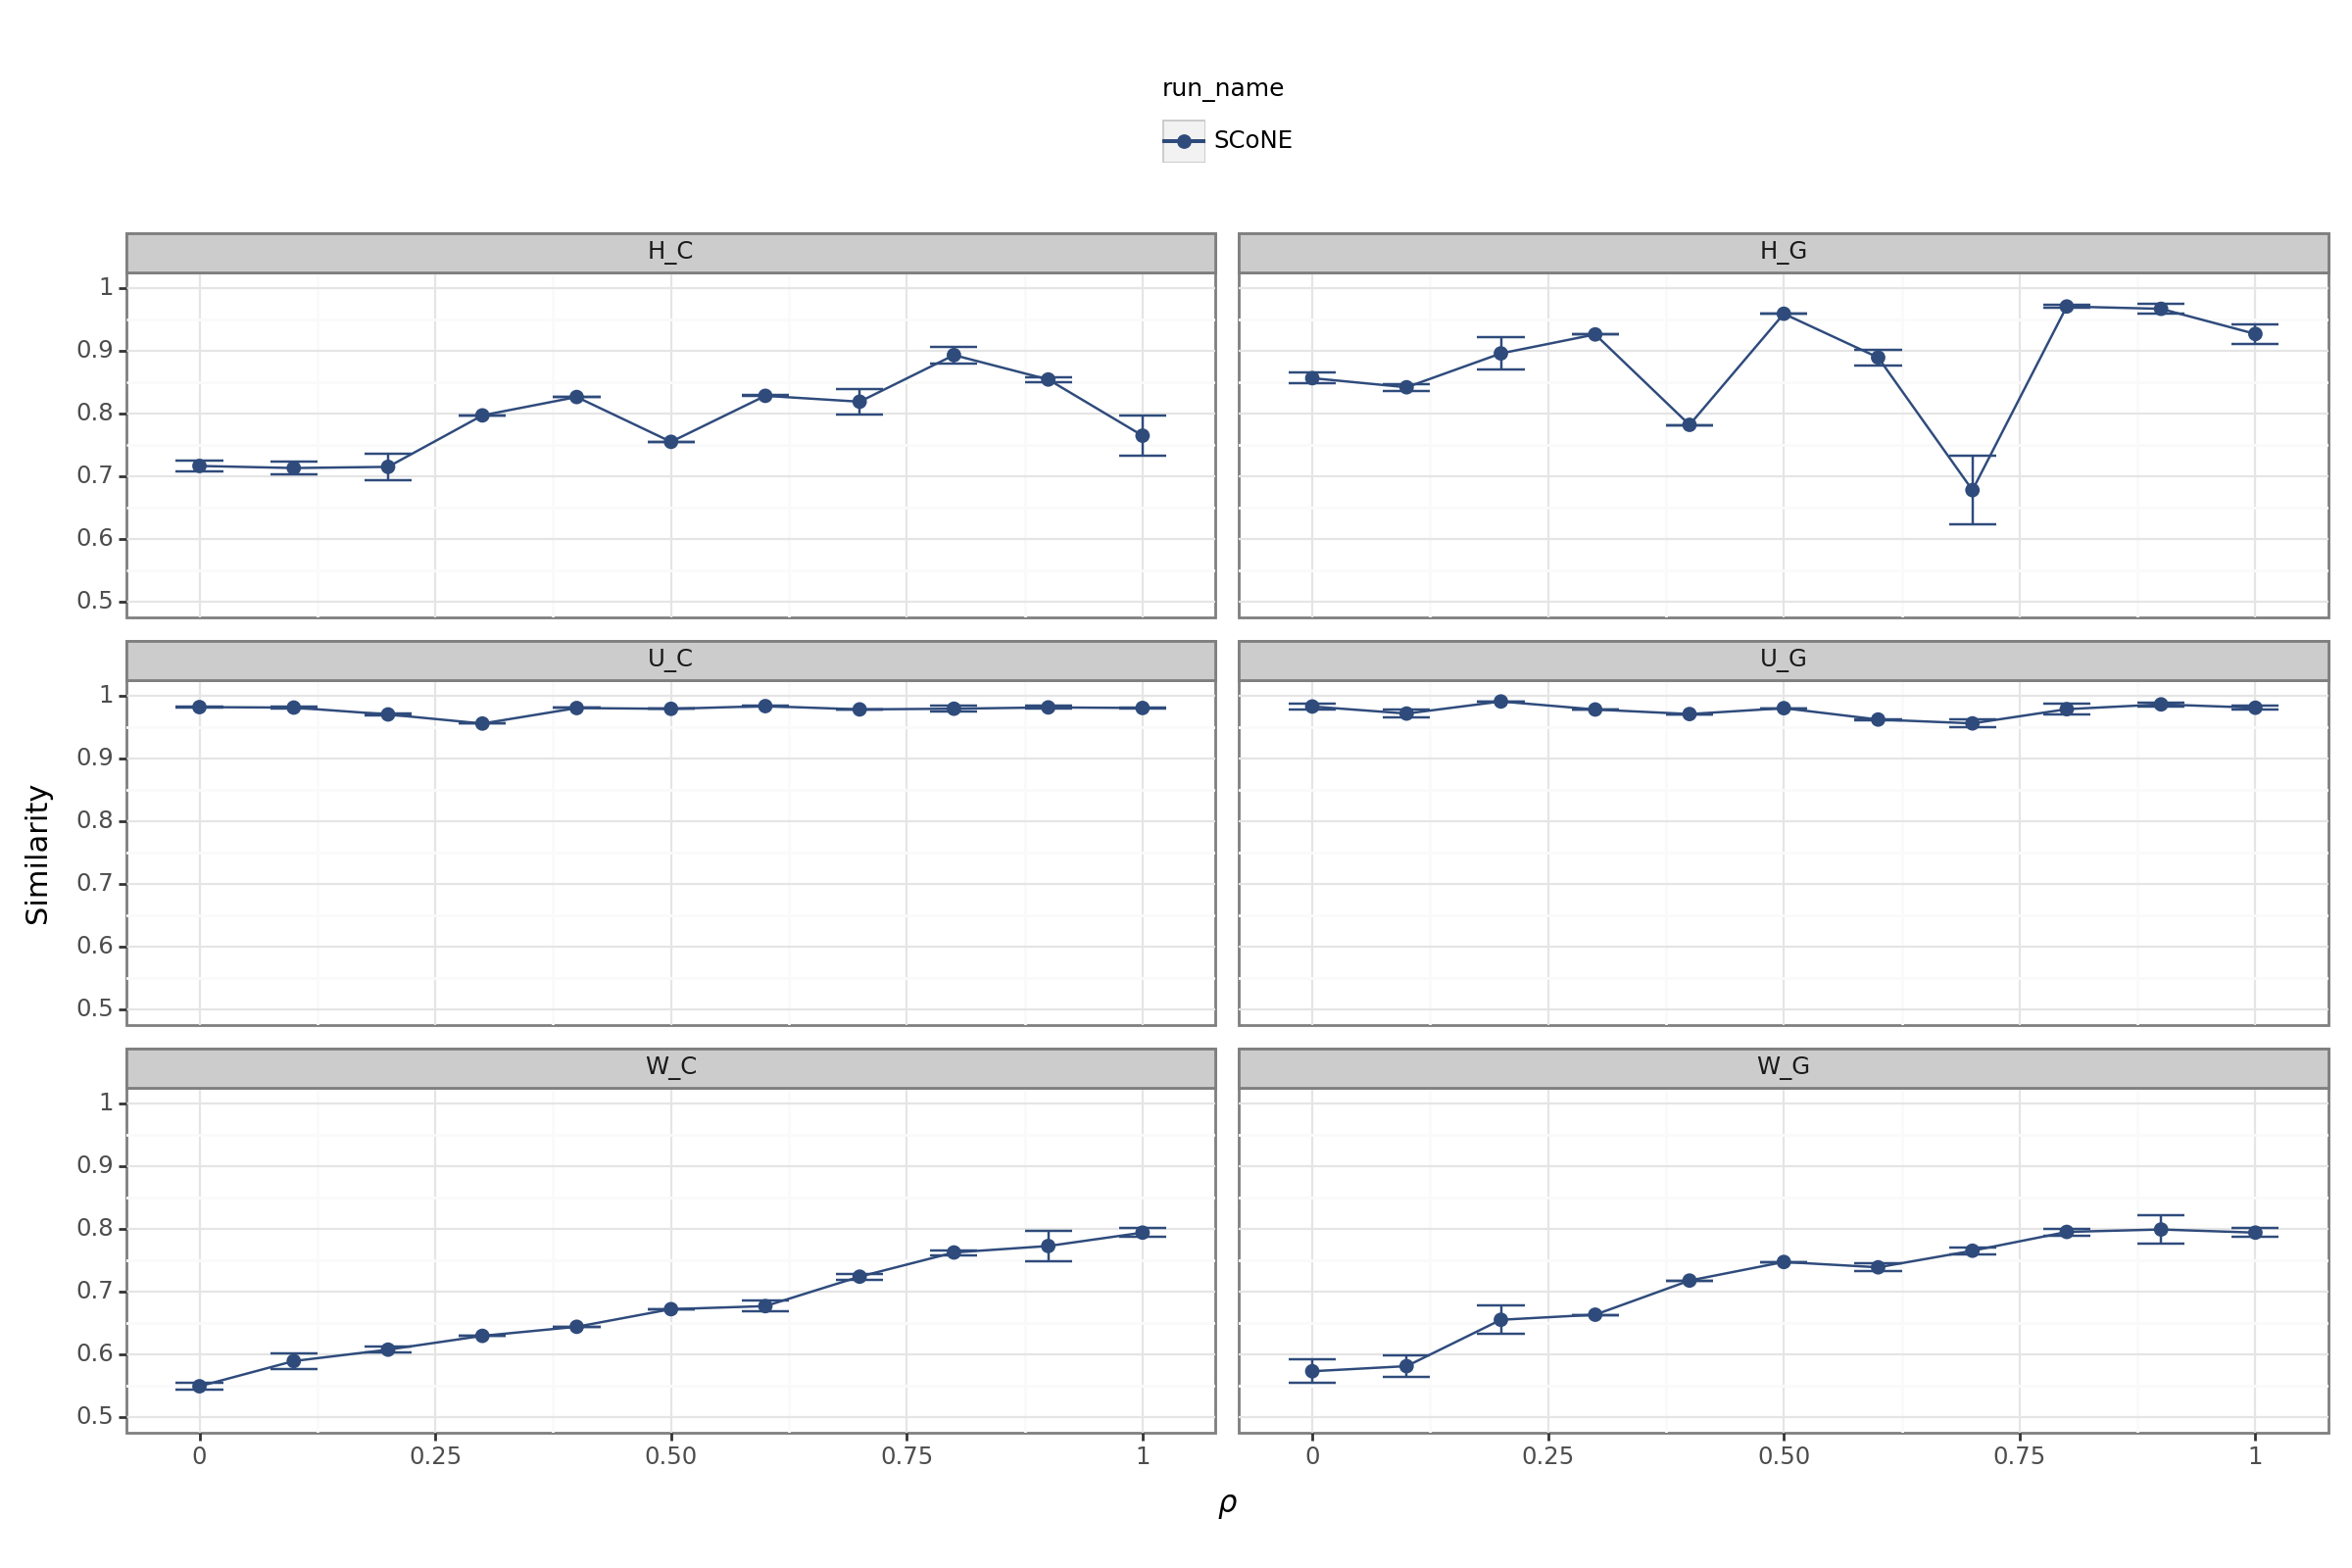

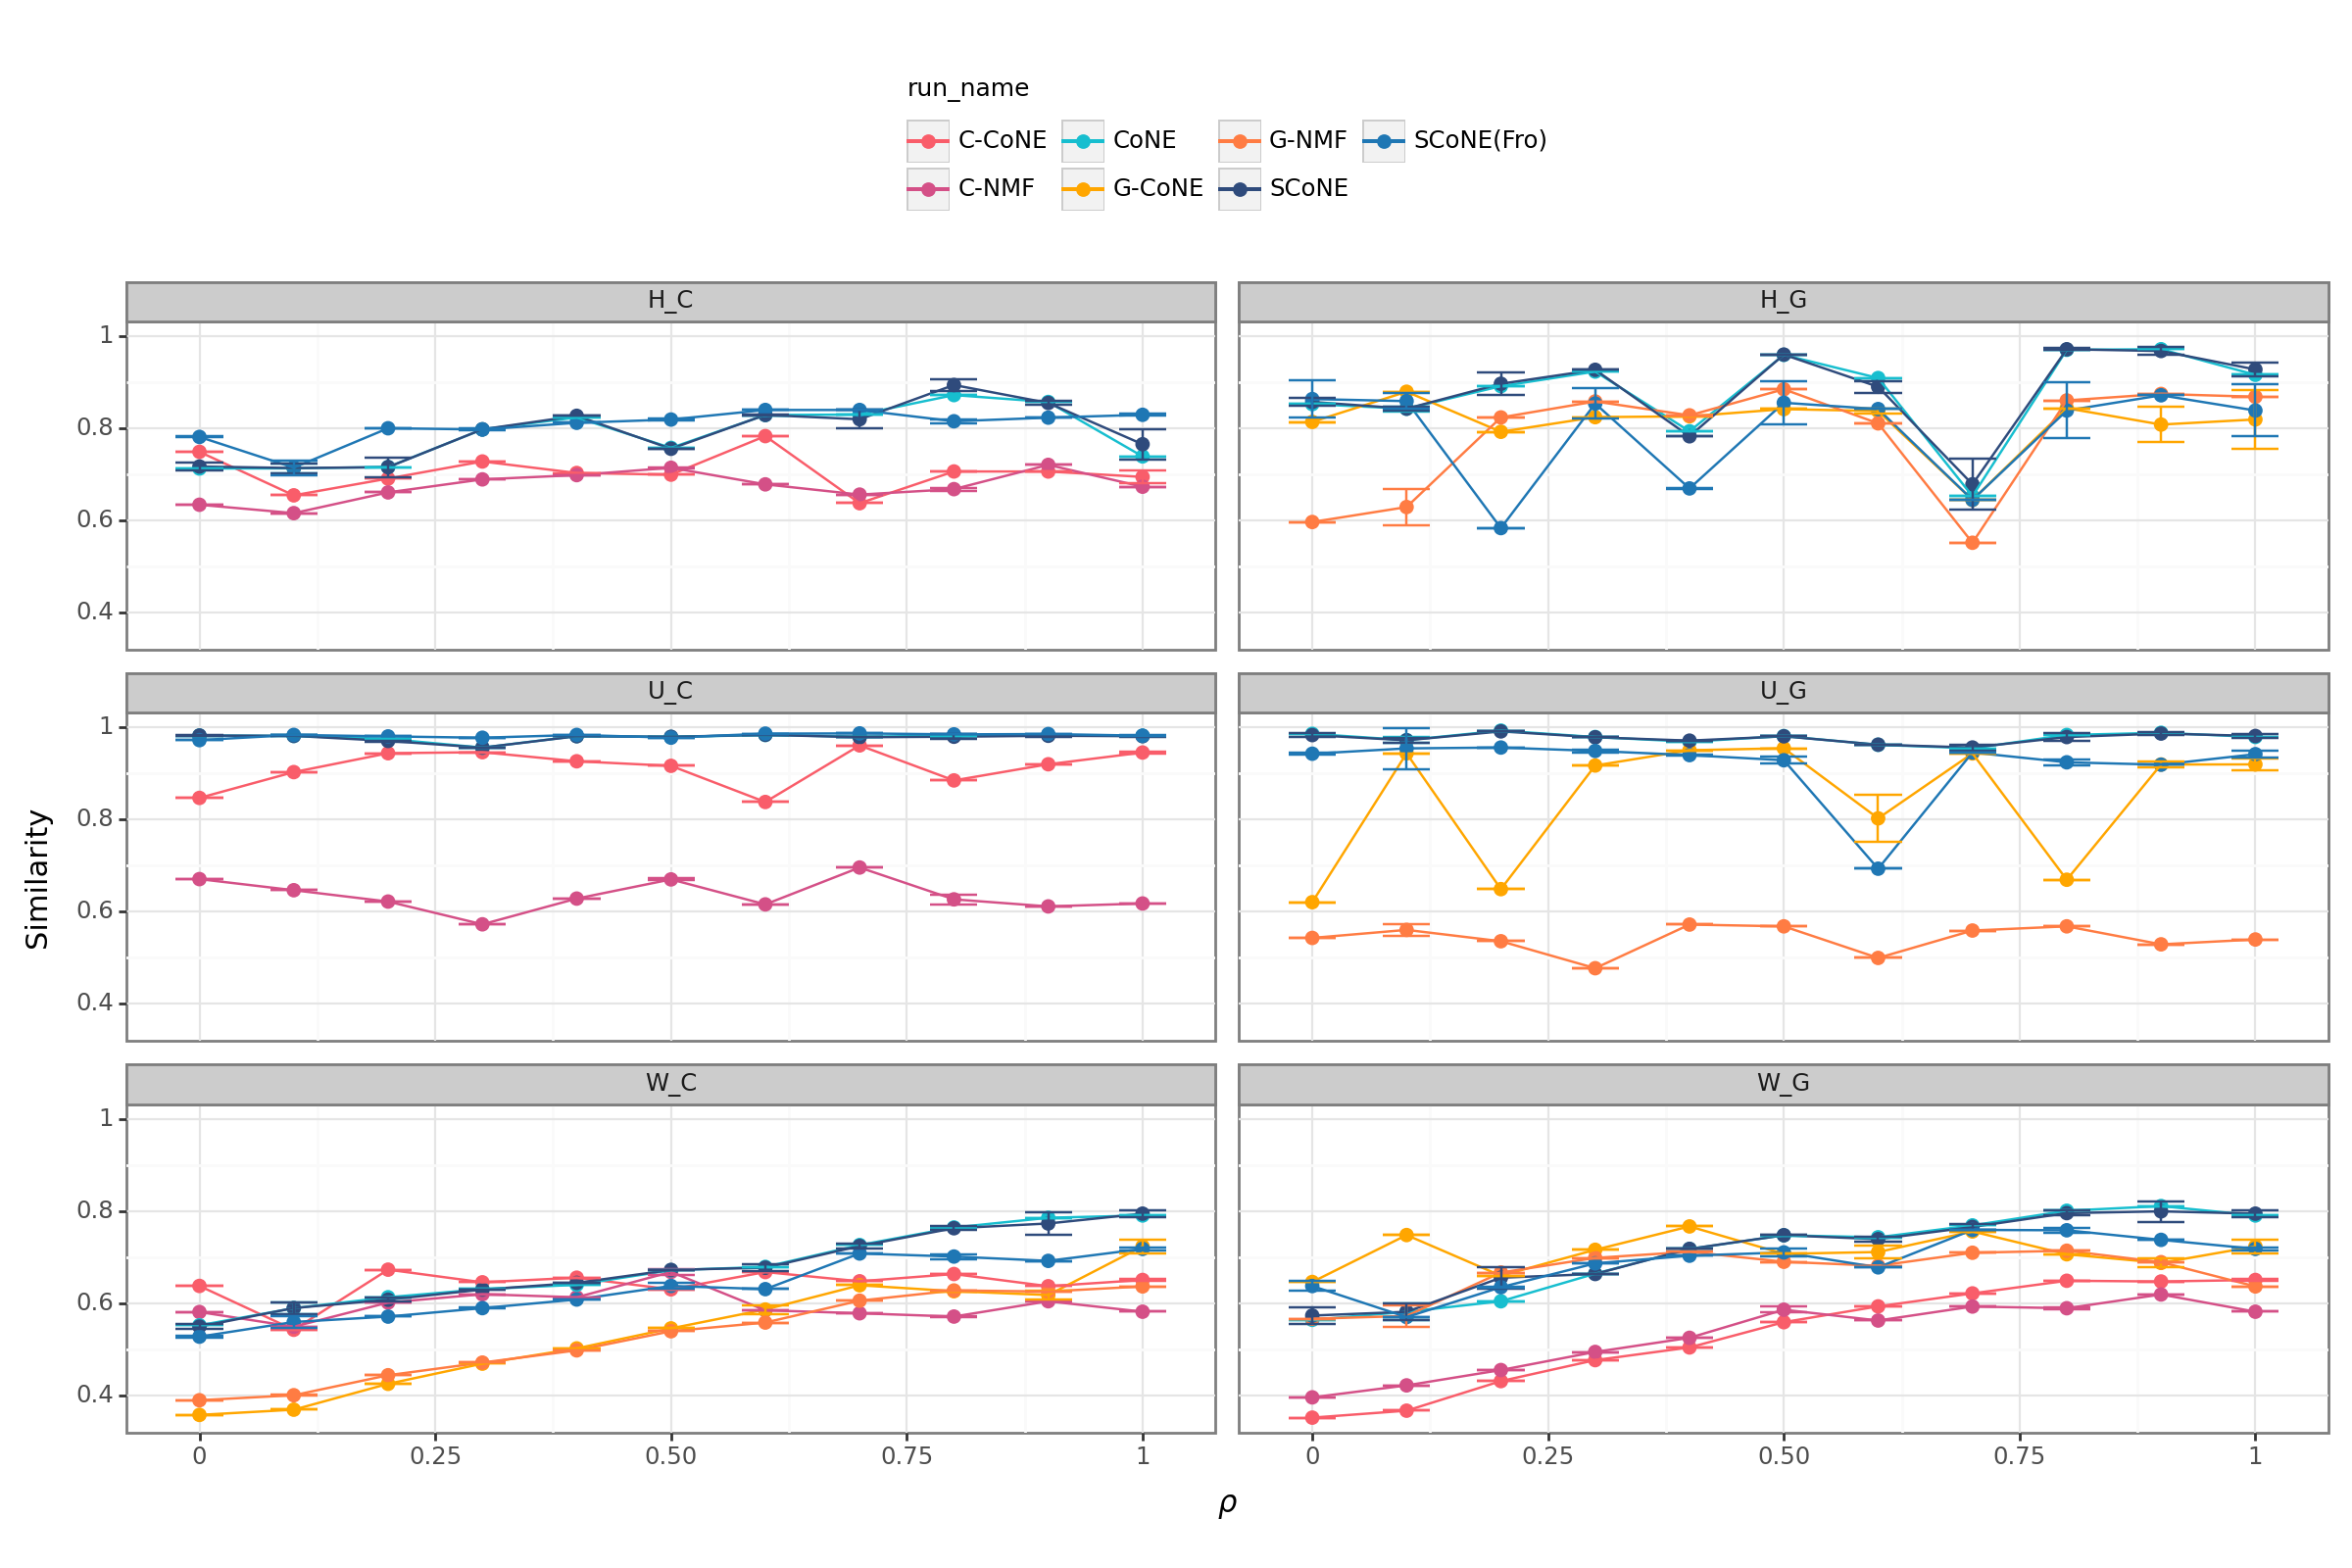

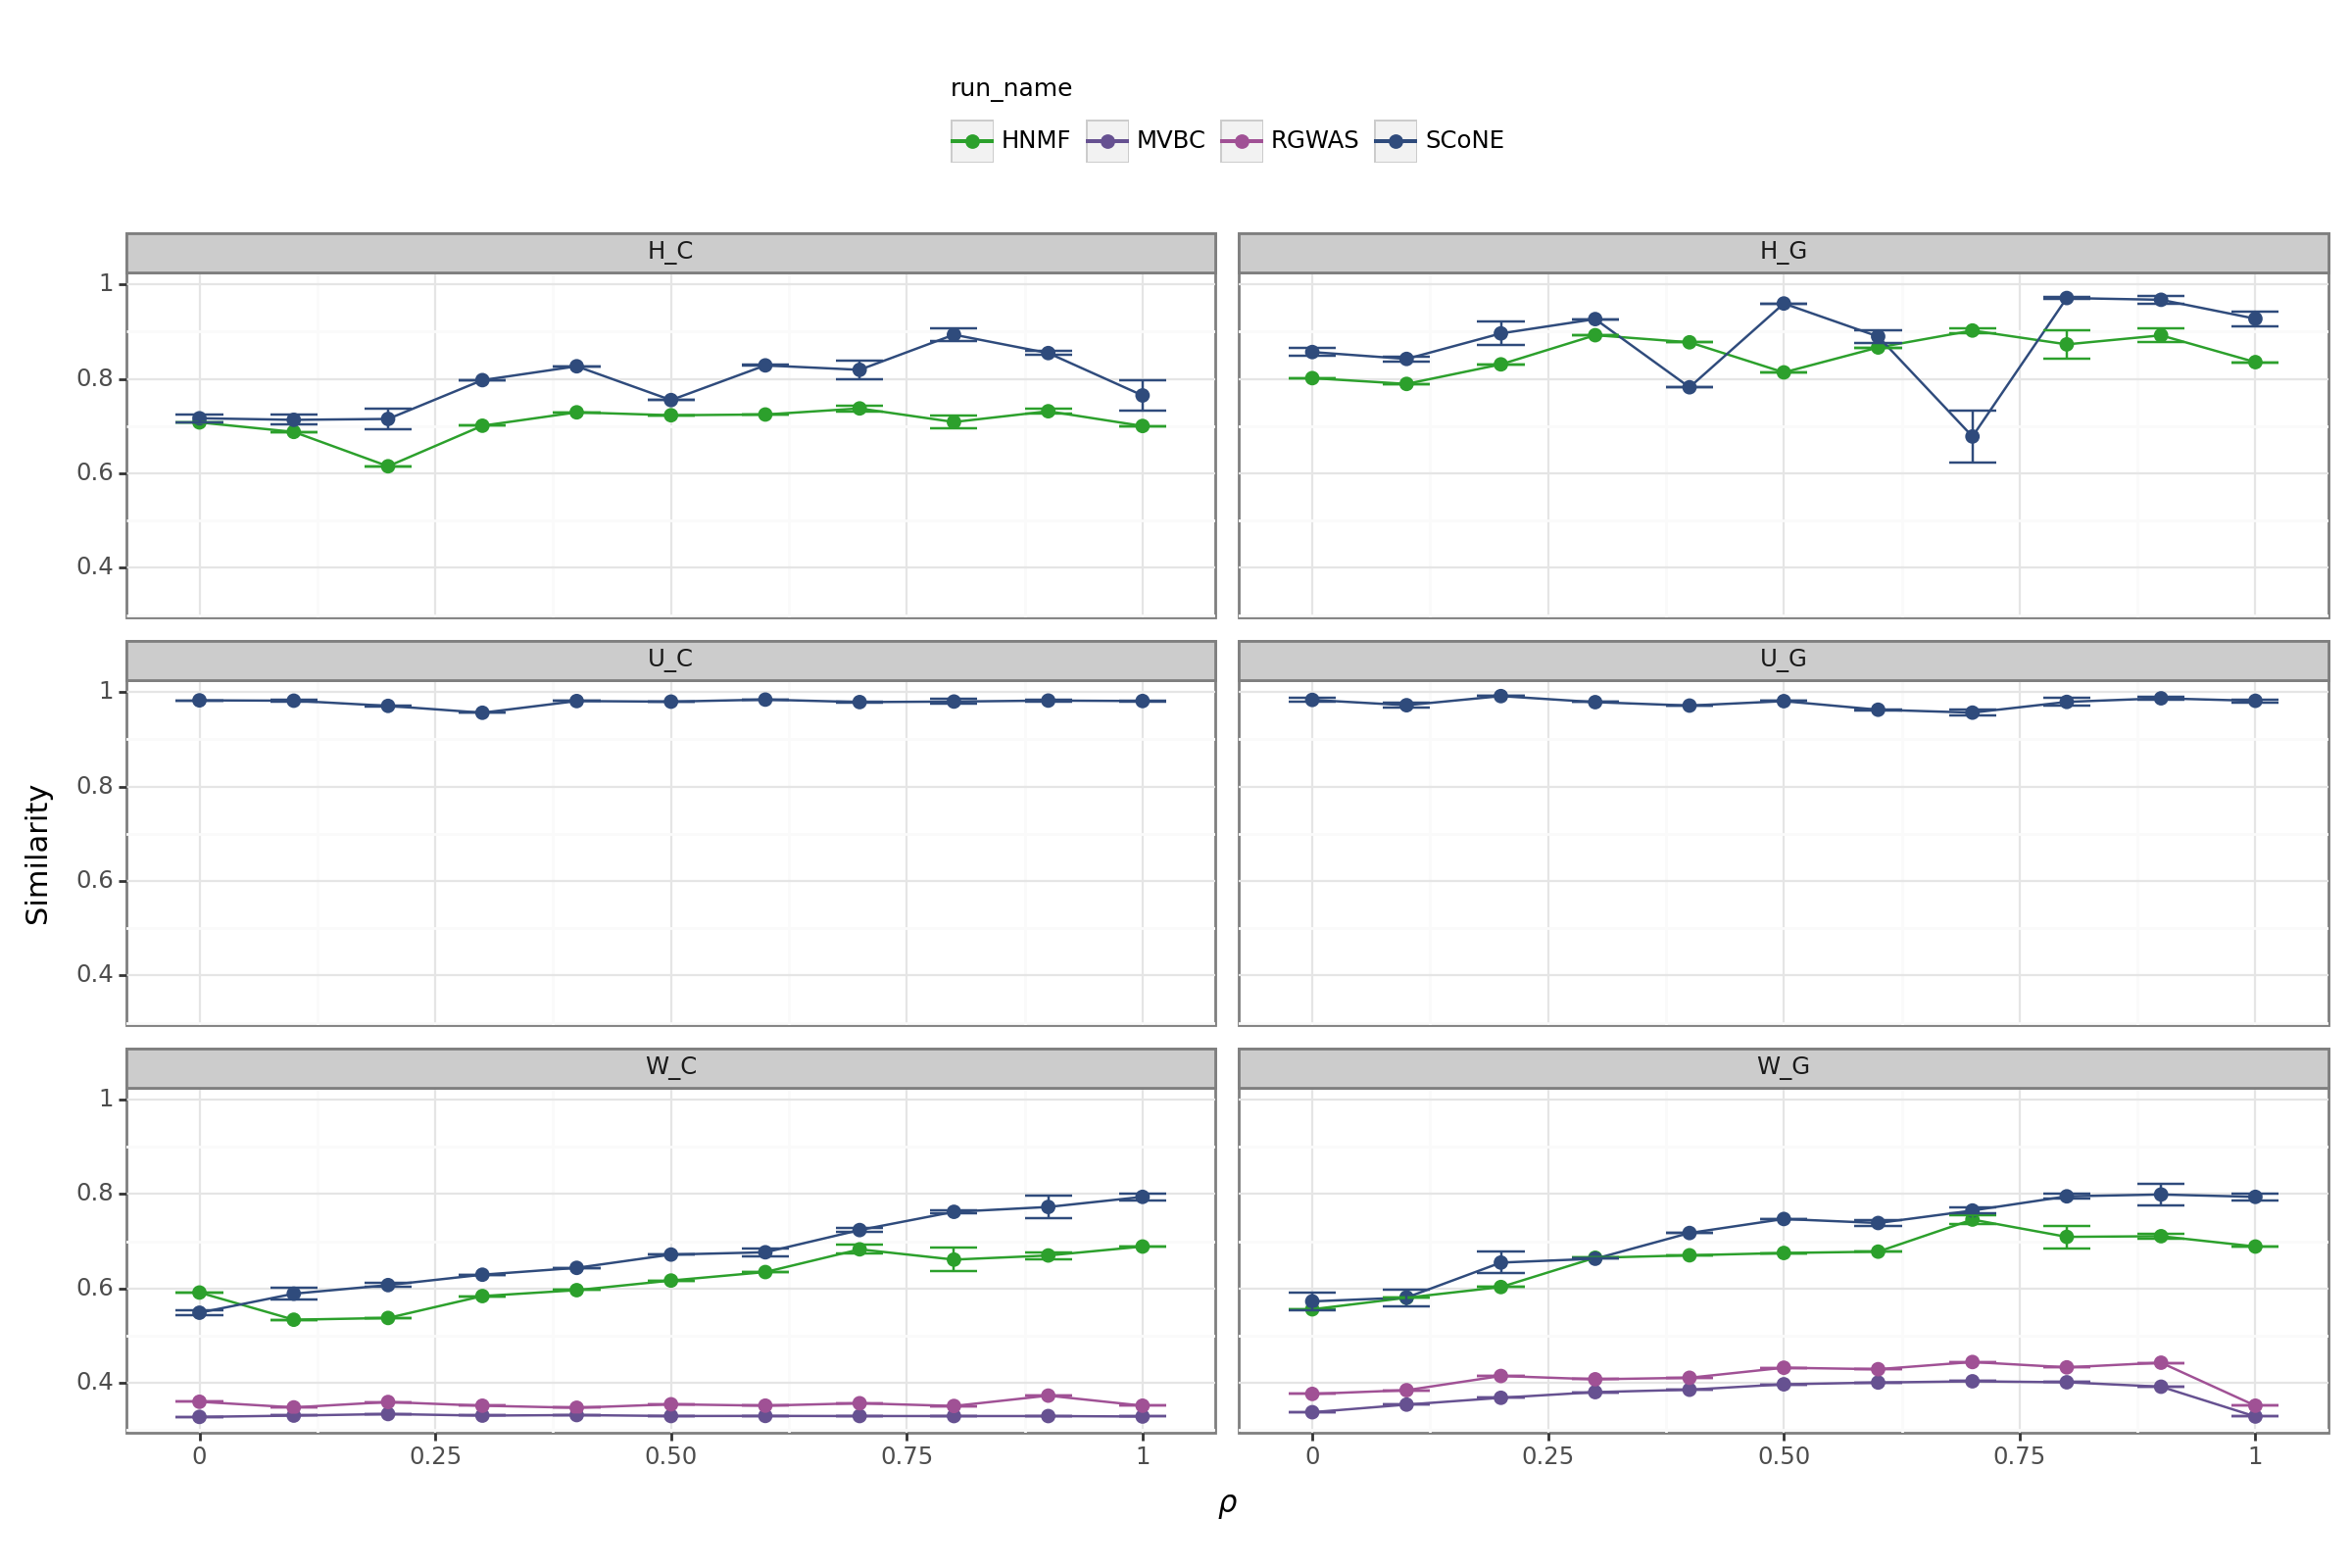

In [3]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/rho_summary.csv',index_col=0)
summary = summary[~((summary['run_name']=='HNMF')&(summary['factor_matrix'].str.startswith('U')))]
graph_plots(summary,"rho",r'$\rho$')

# Assess runs over ZU weight

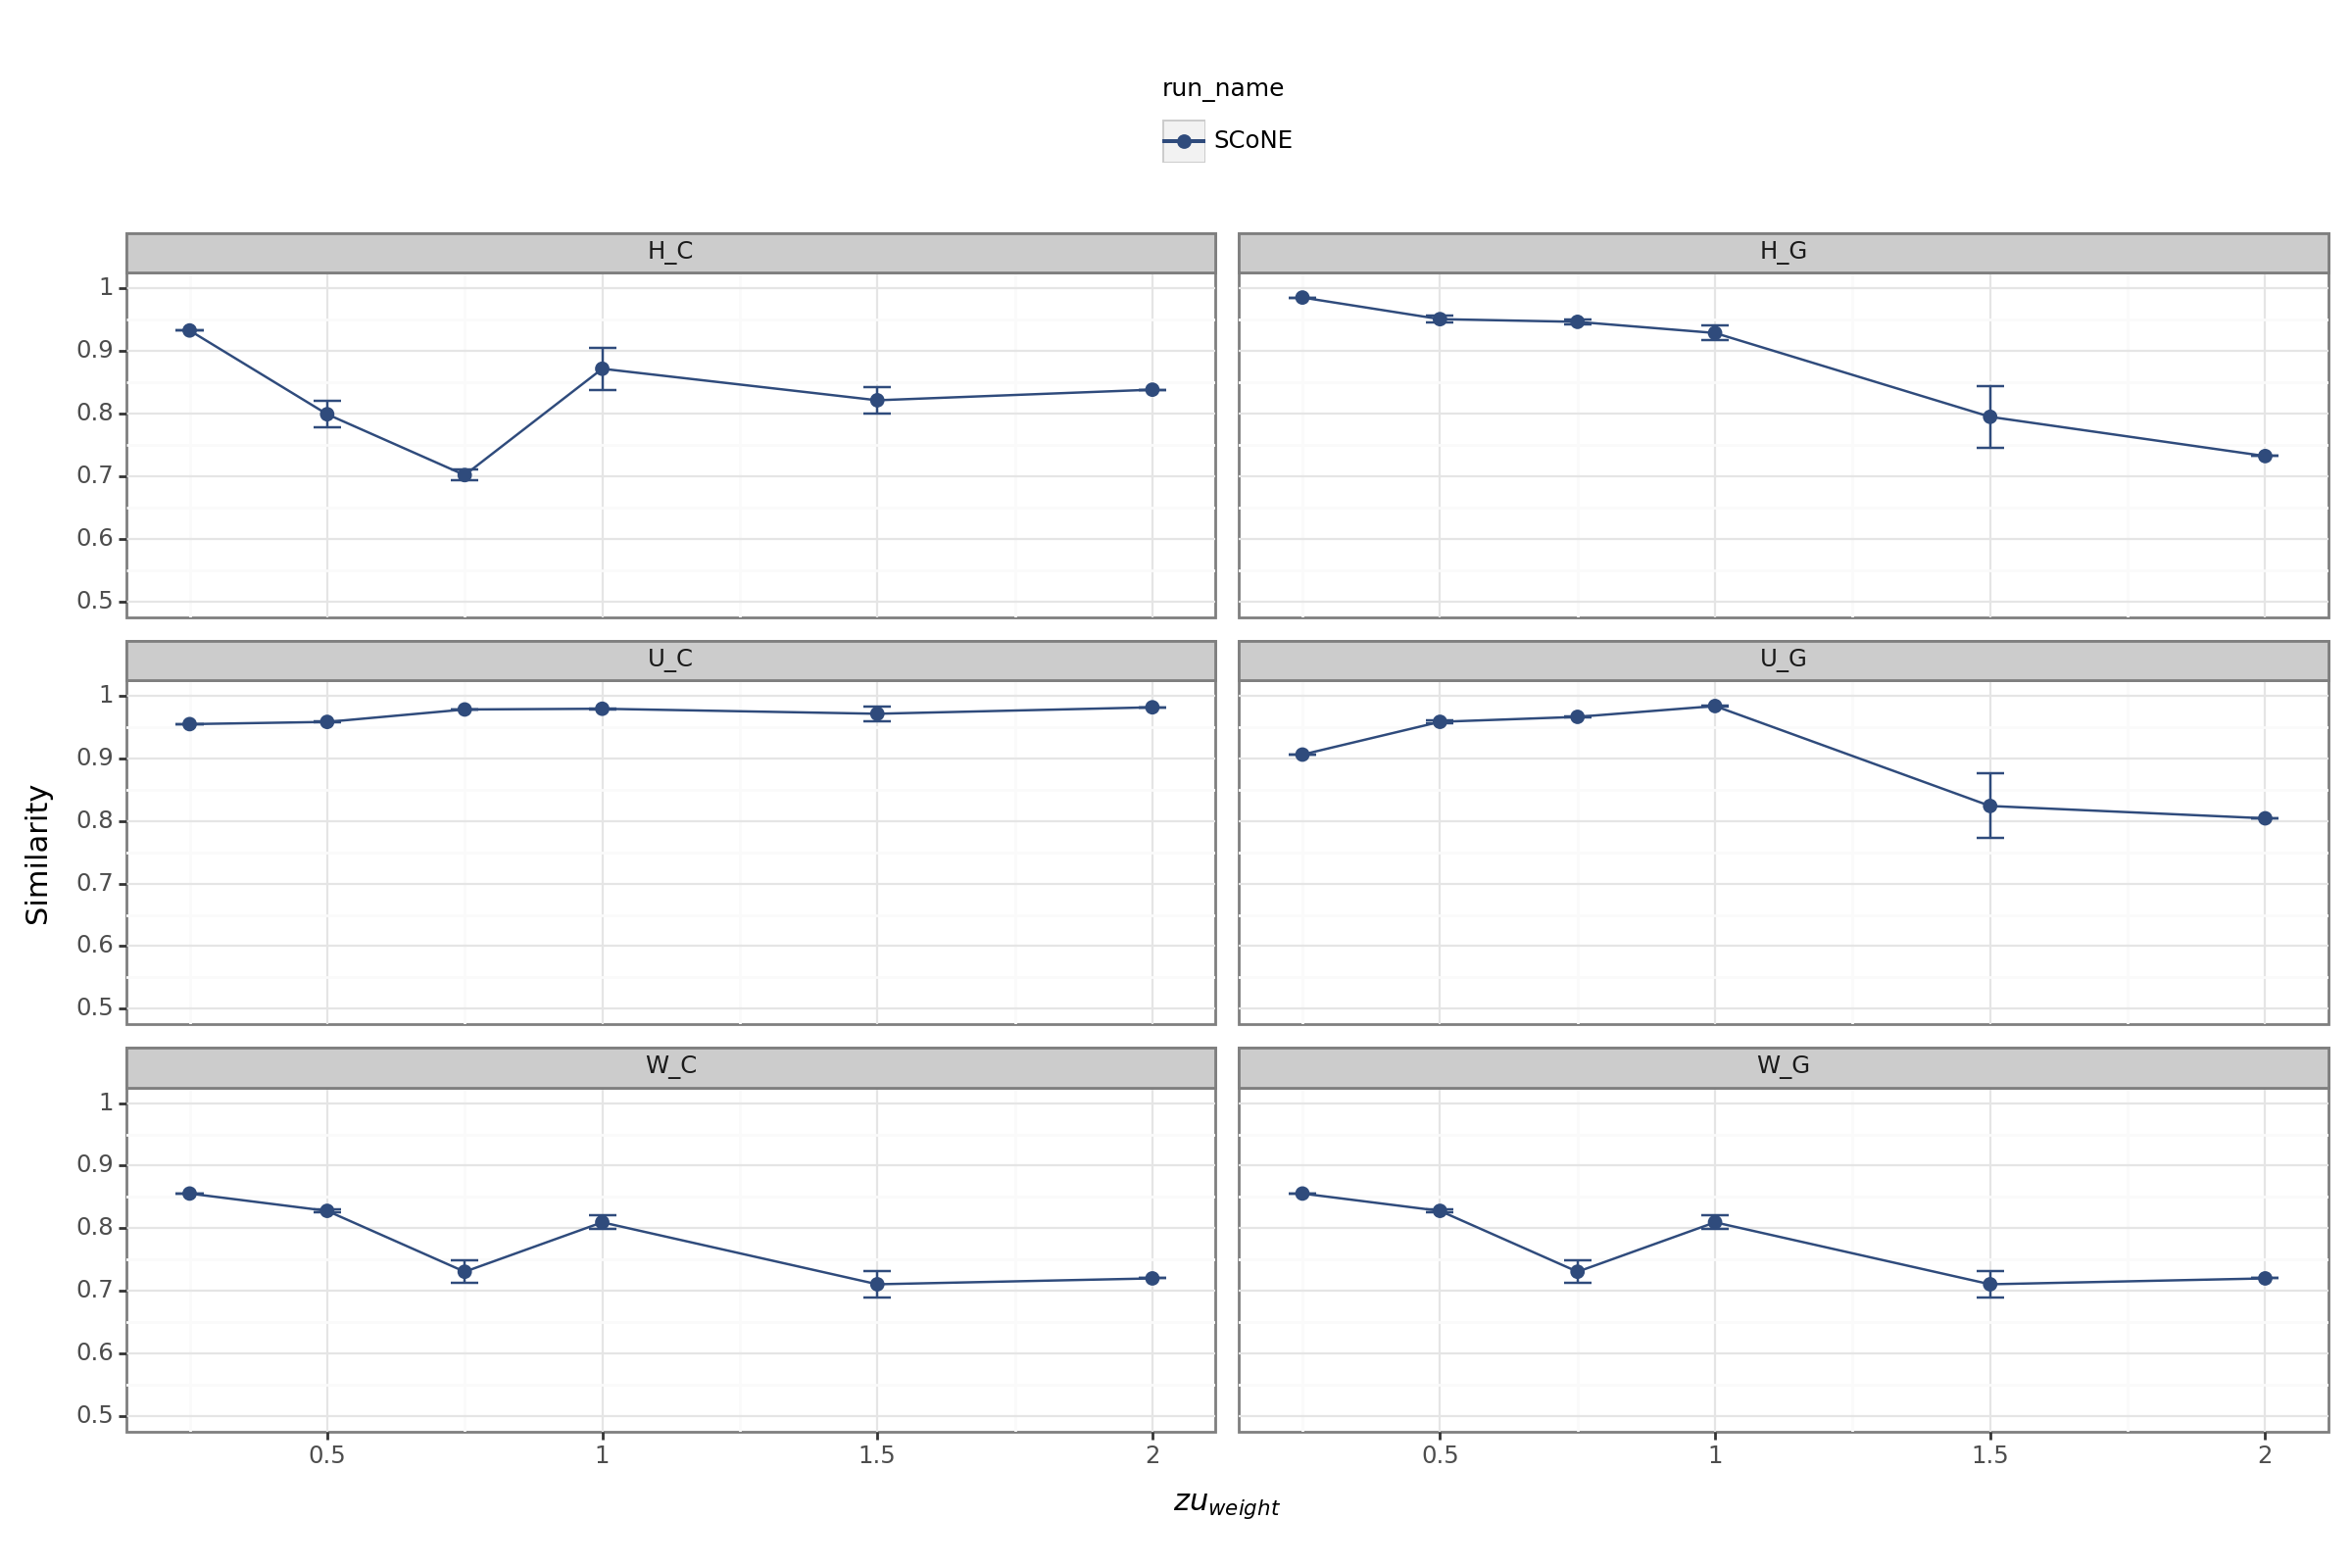

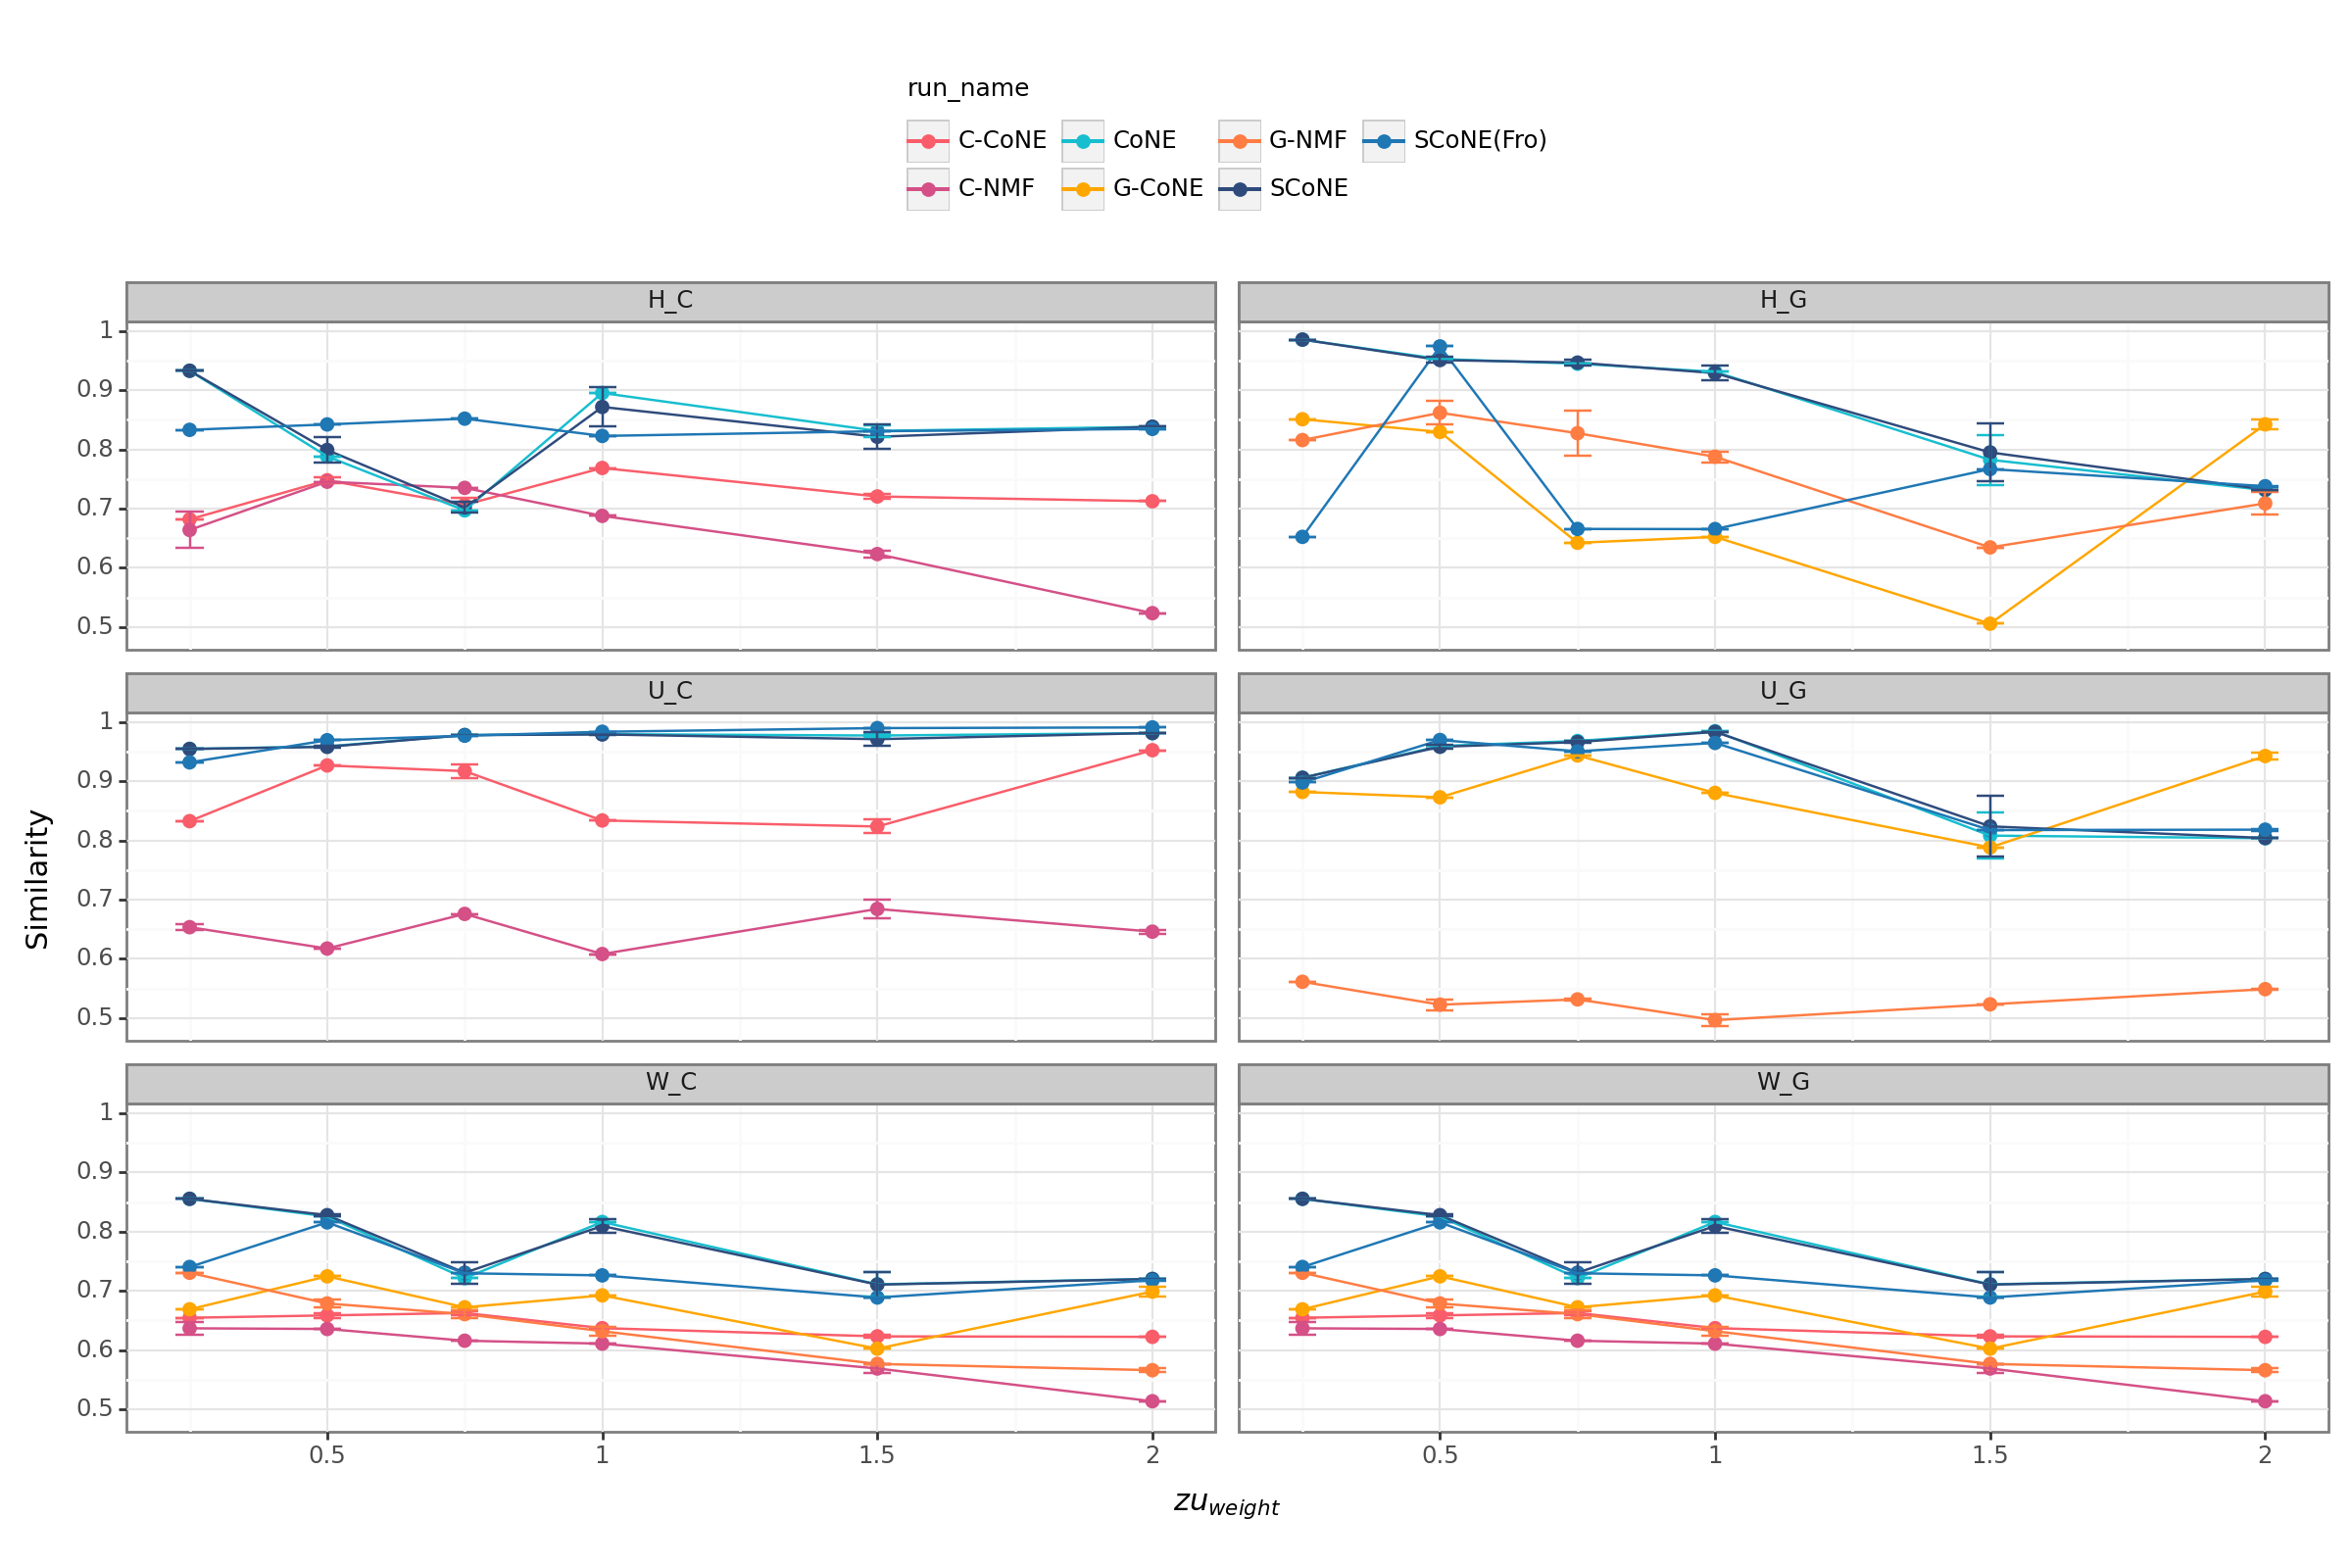

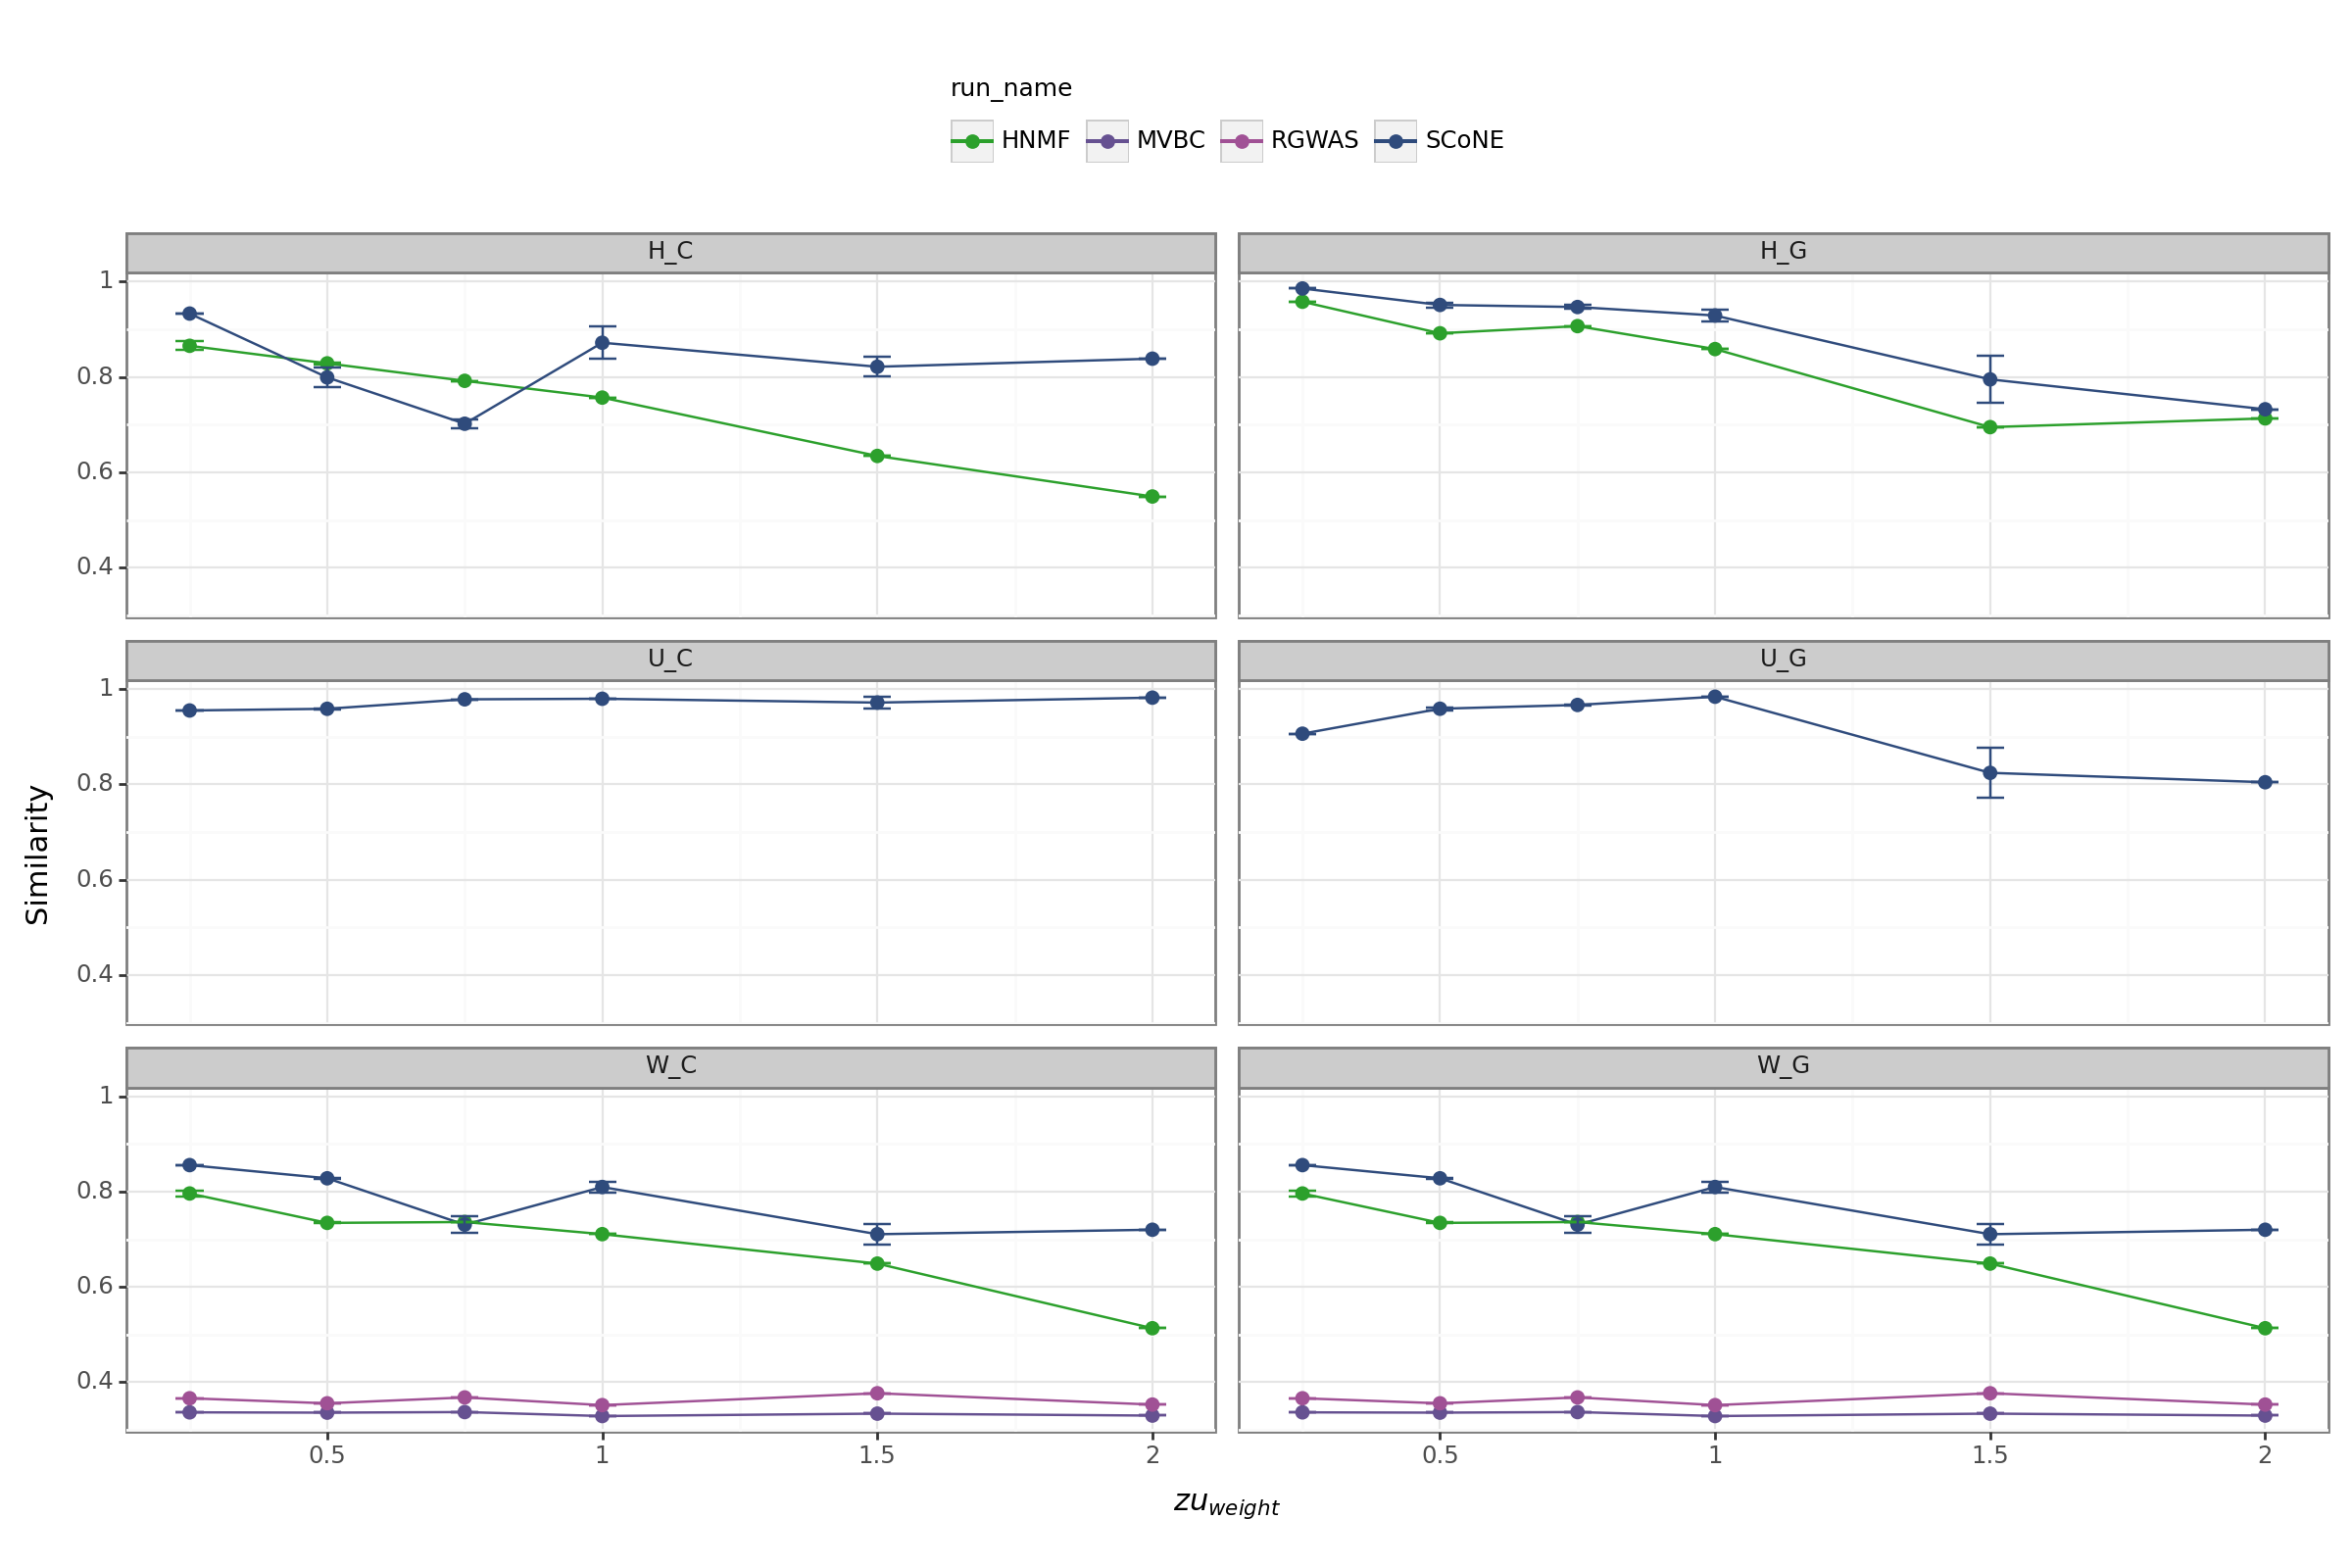

In [4]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/zu_weight_summary.csv',index_col=0)
summary = summary[~((summary['run_name']=='HNMF')&(summary['factor_matrix'].str.startswith('U')))]
graph_plots(summary,"ZU_weight",r'$zu_{weight}$')

# Assess runs over noise

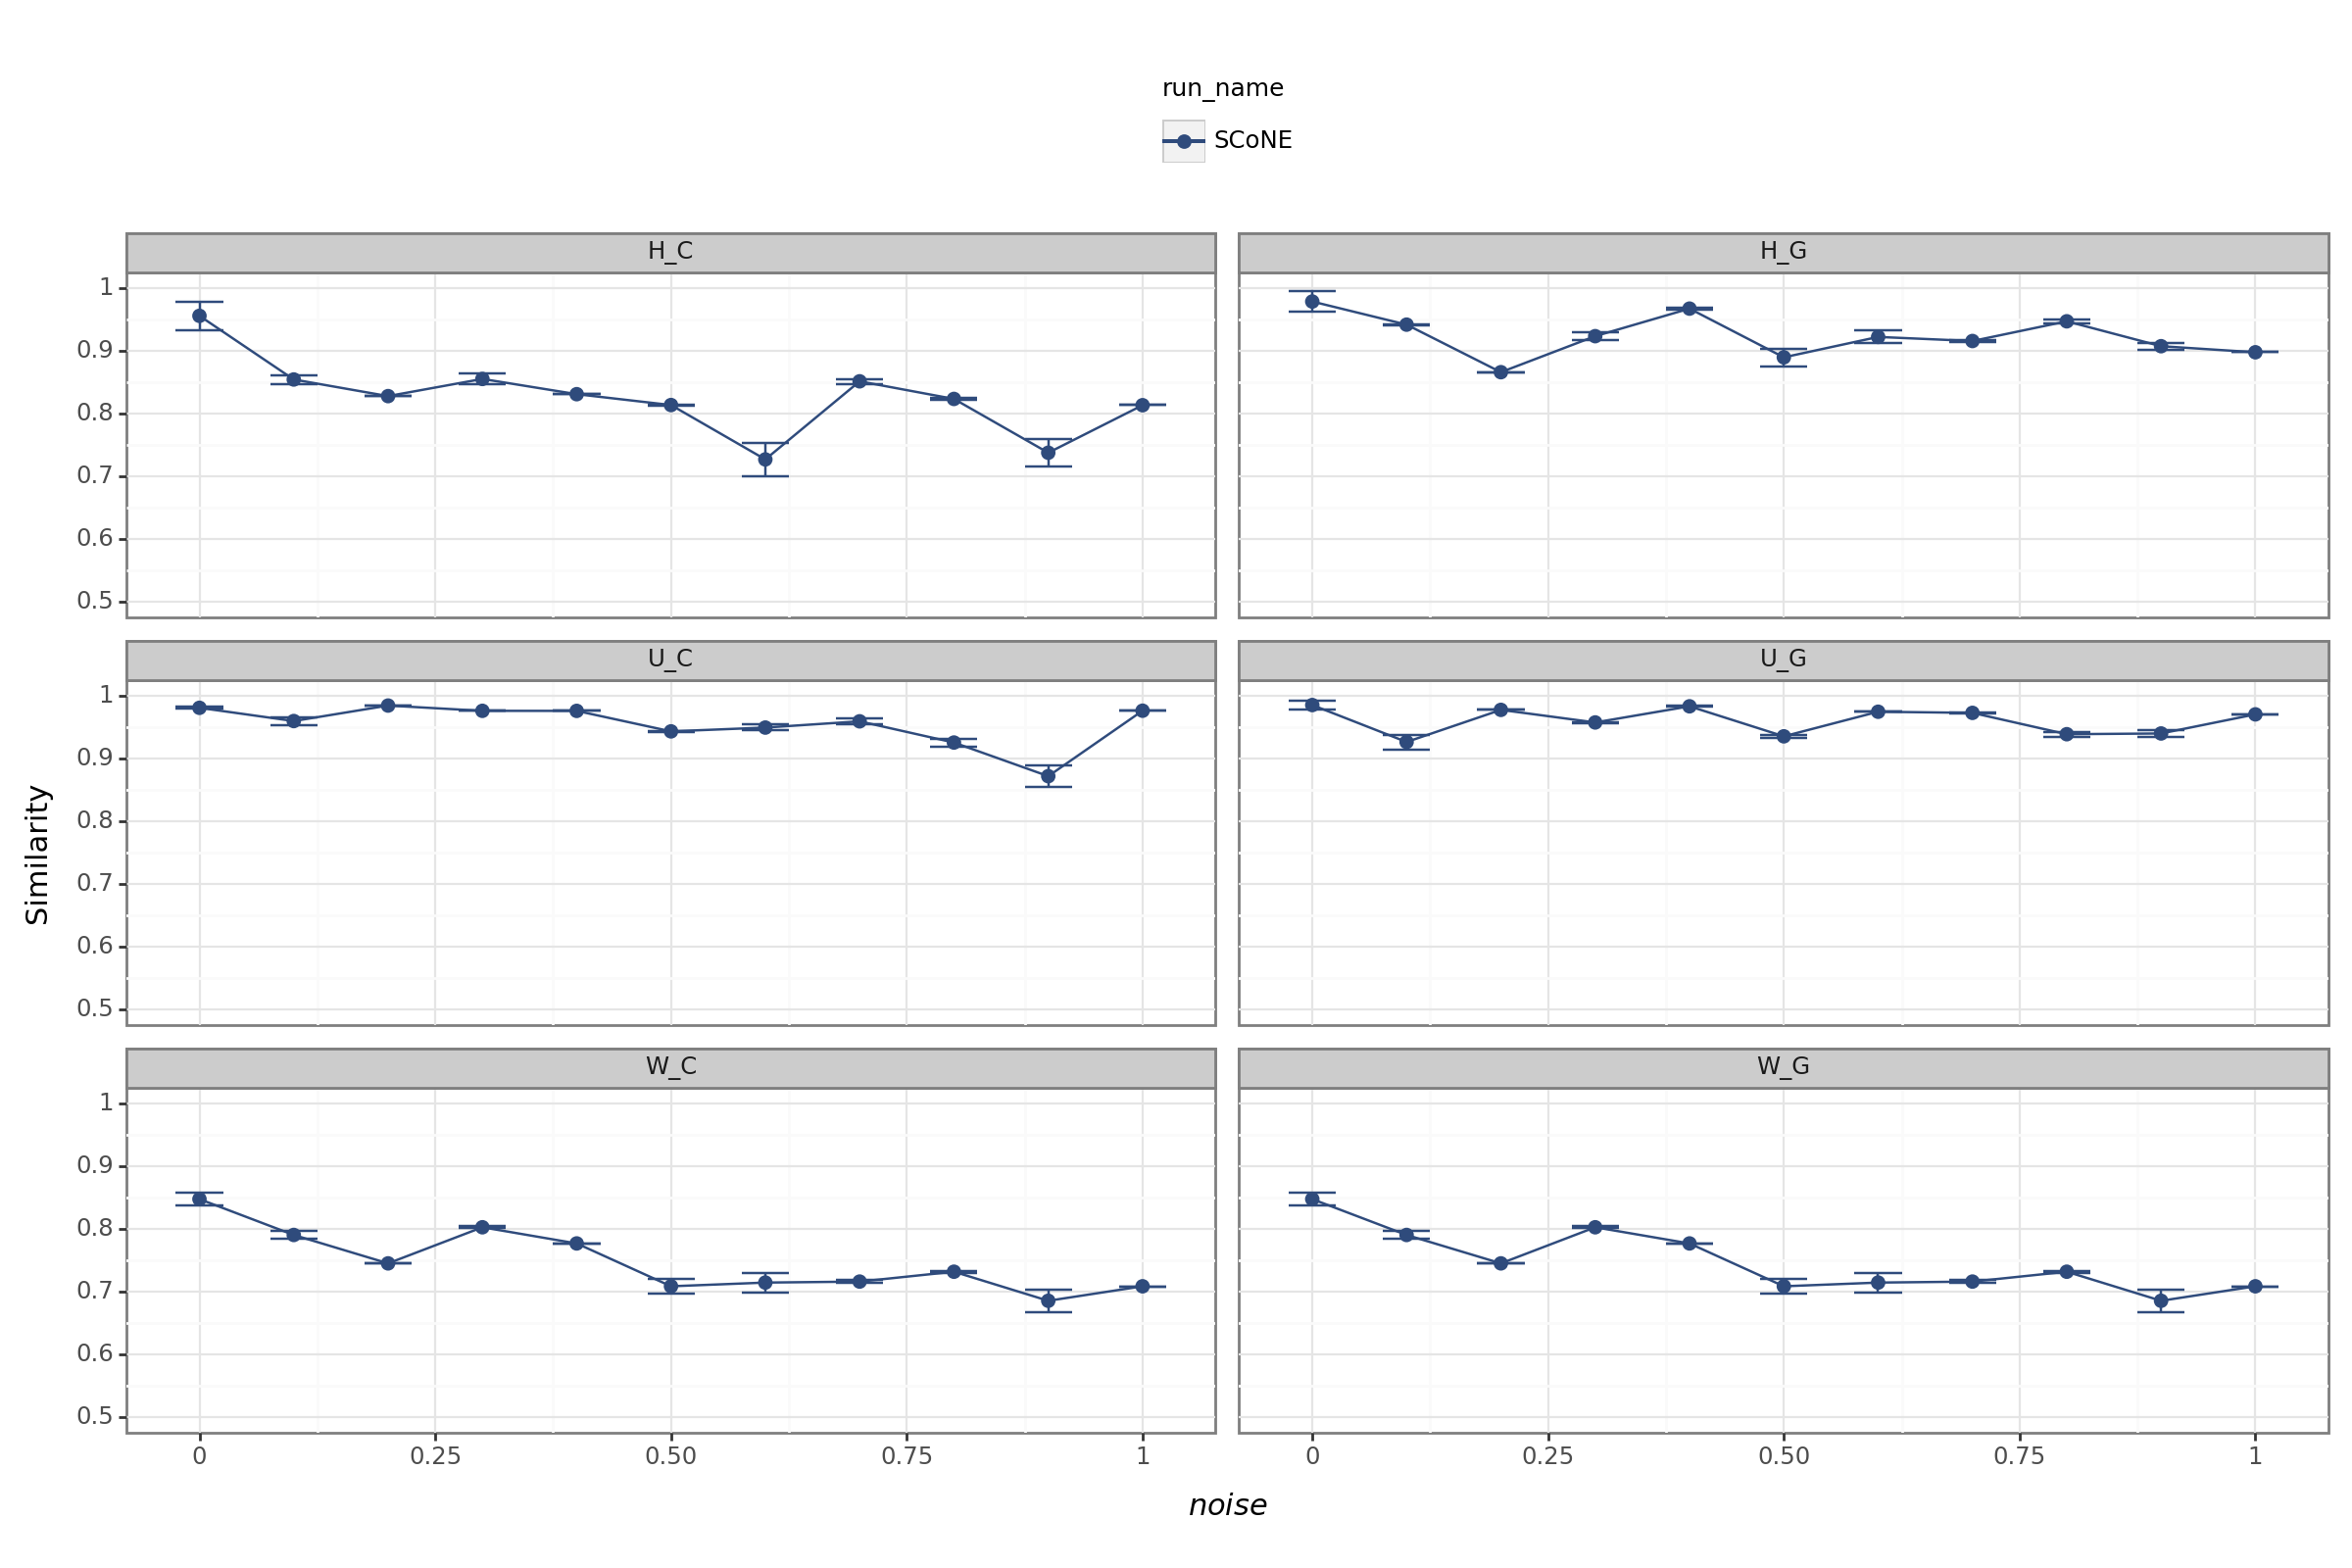

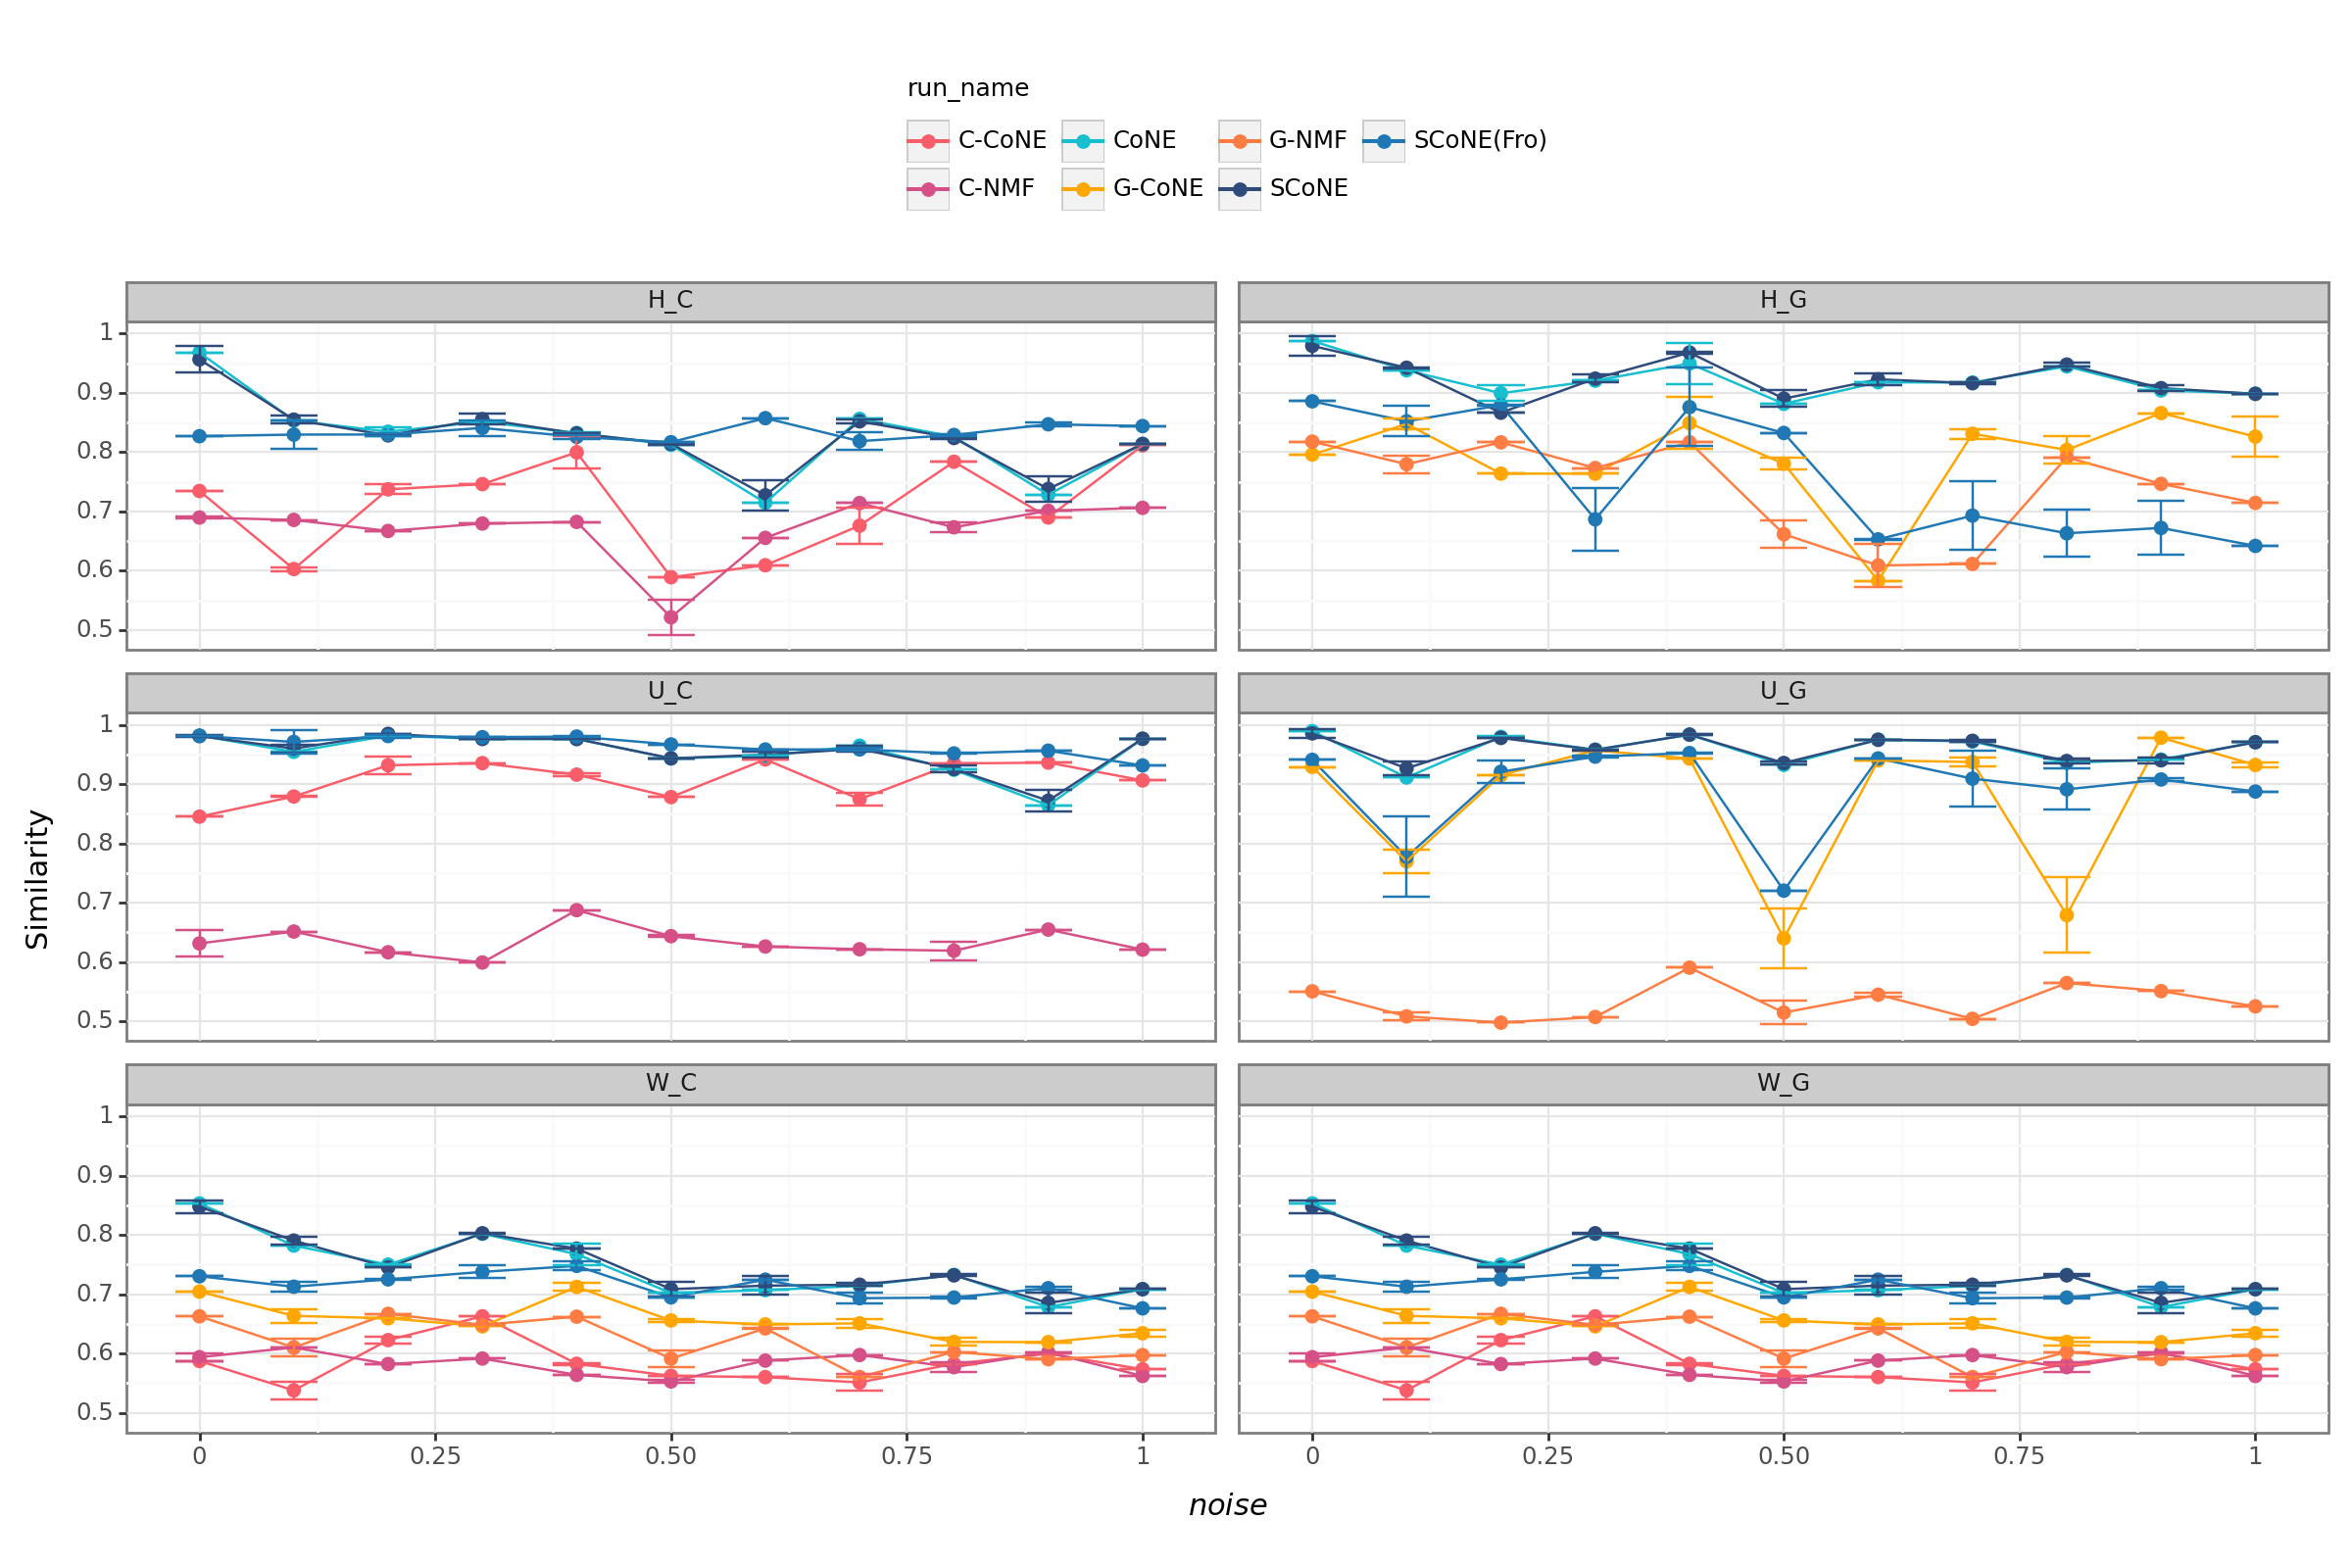

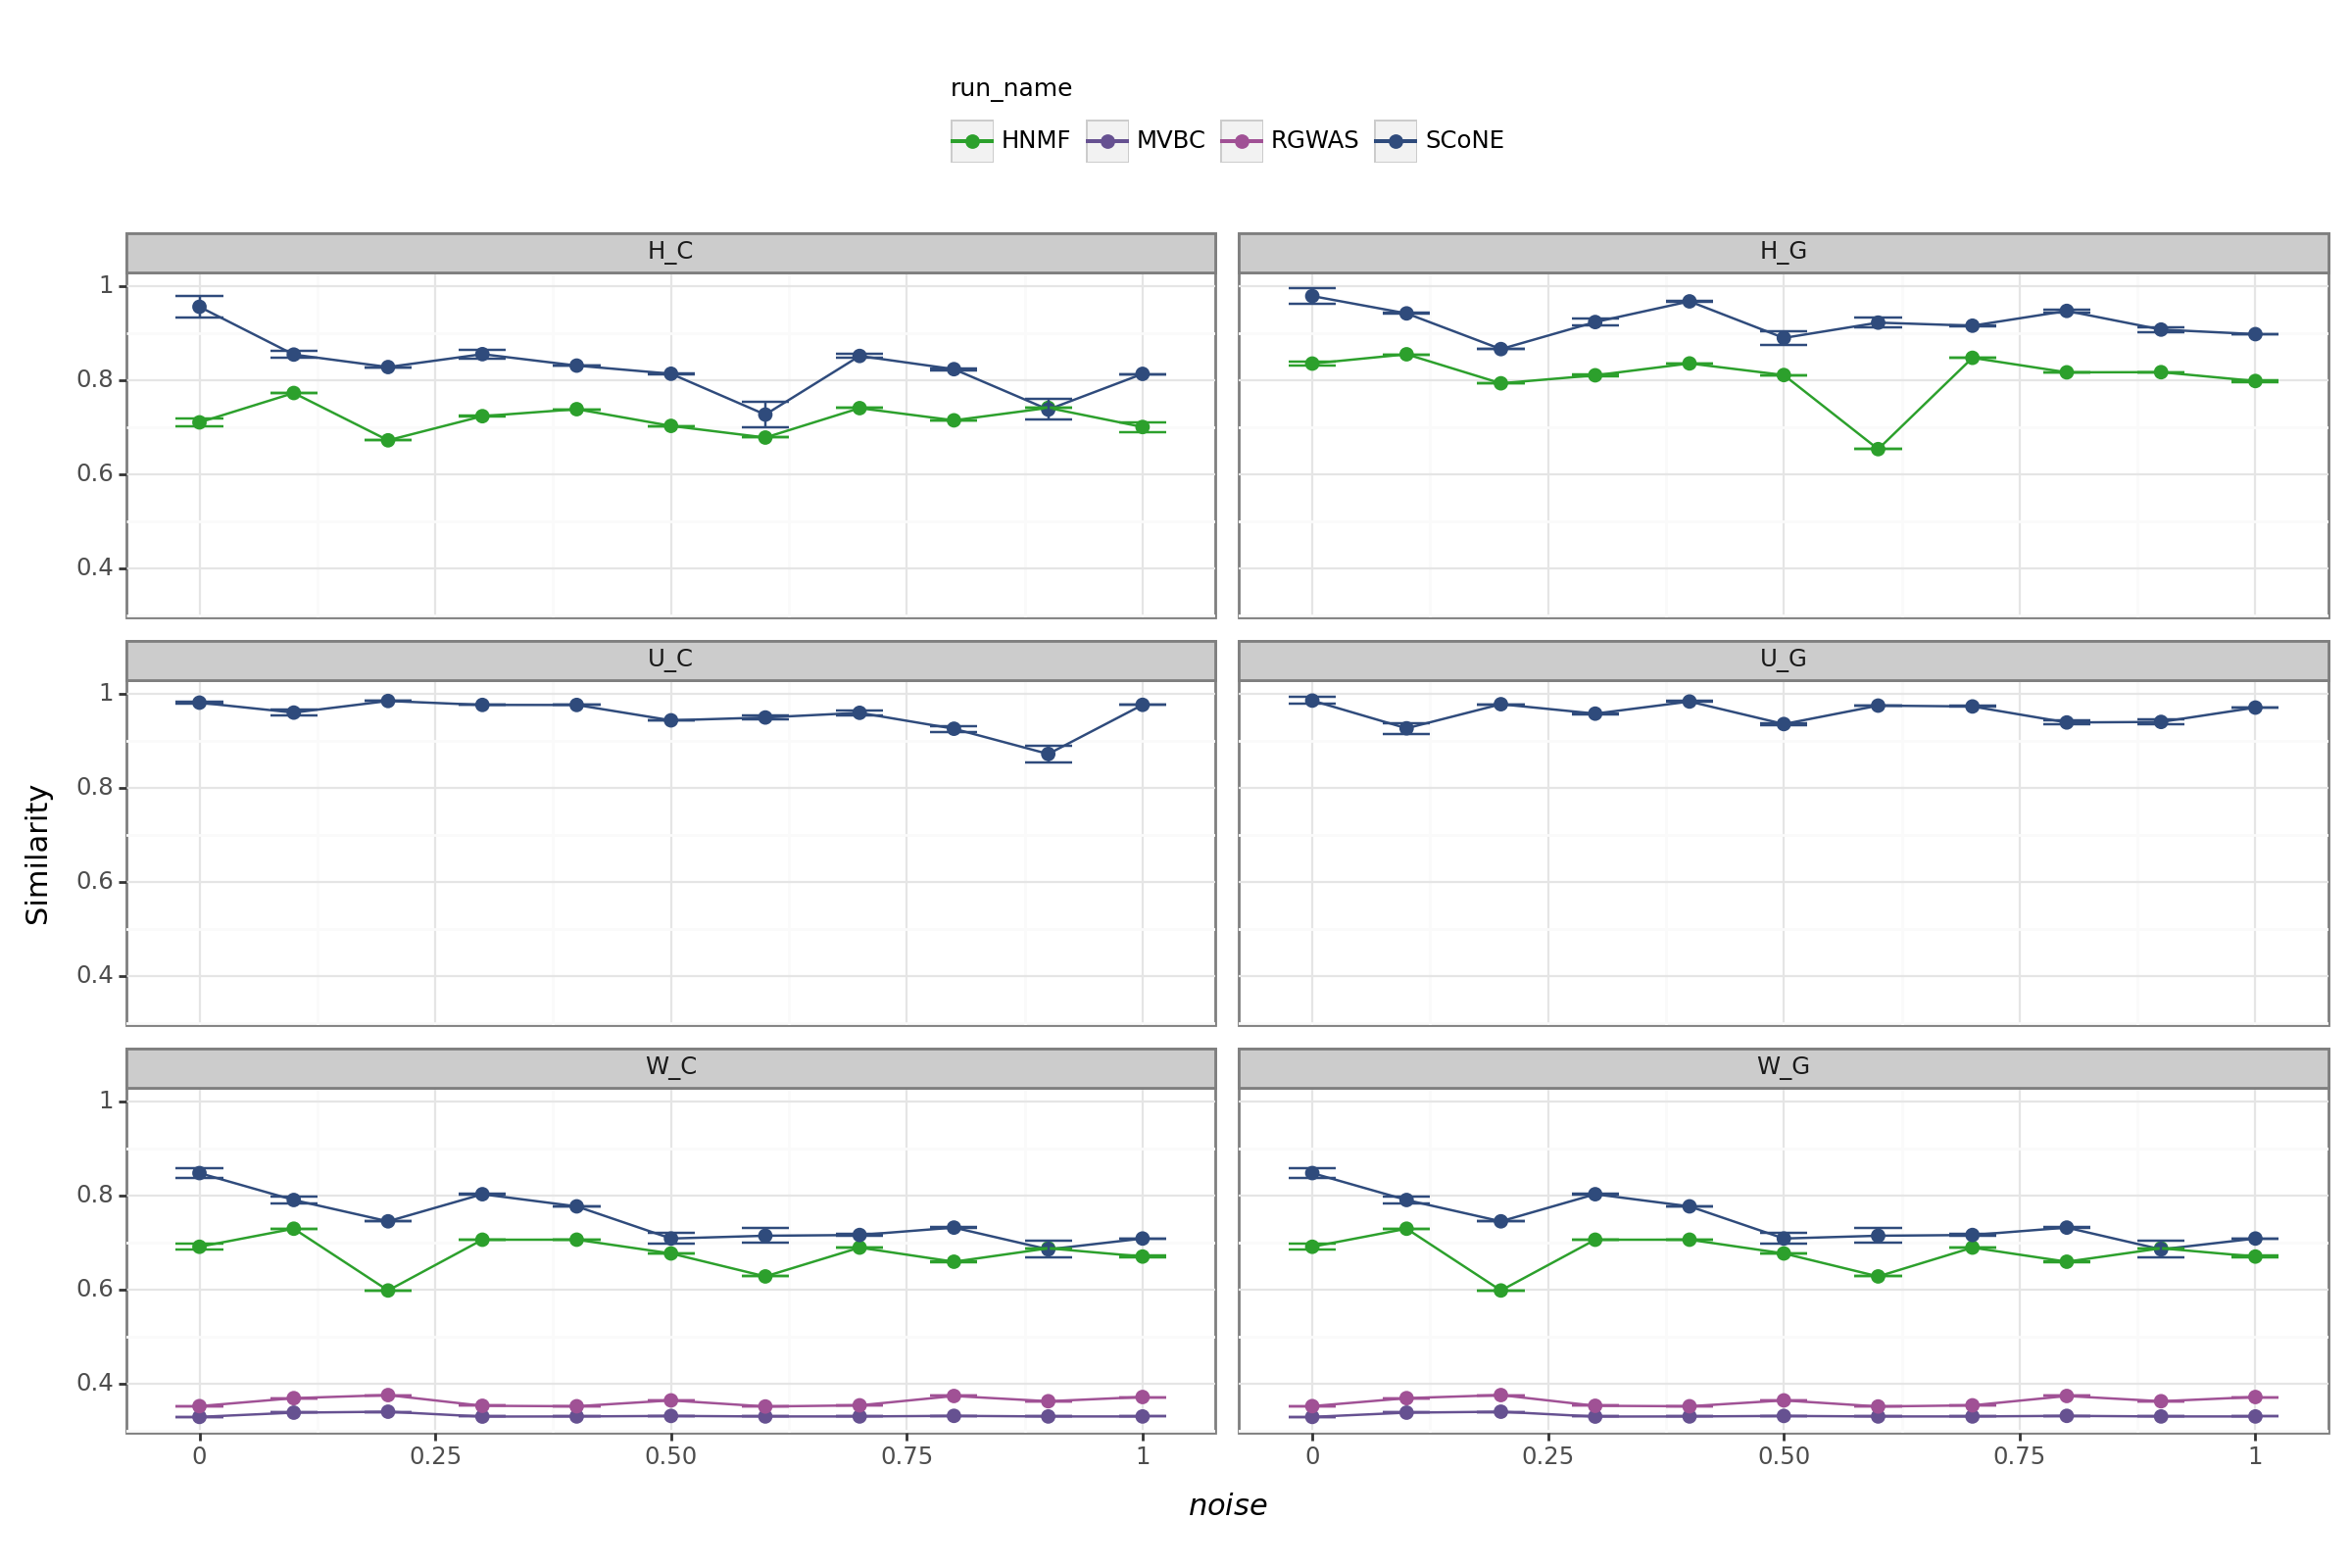

In [5]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/noise_summary.csv',index_col=0)
summary = summary[~((summary['run_name']=='HNMF')&(summary['factor_matrix'].str.startswith('U')))]
graph_plots(summary,"noise",r'$noise$')

# Assess runs over sparsity

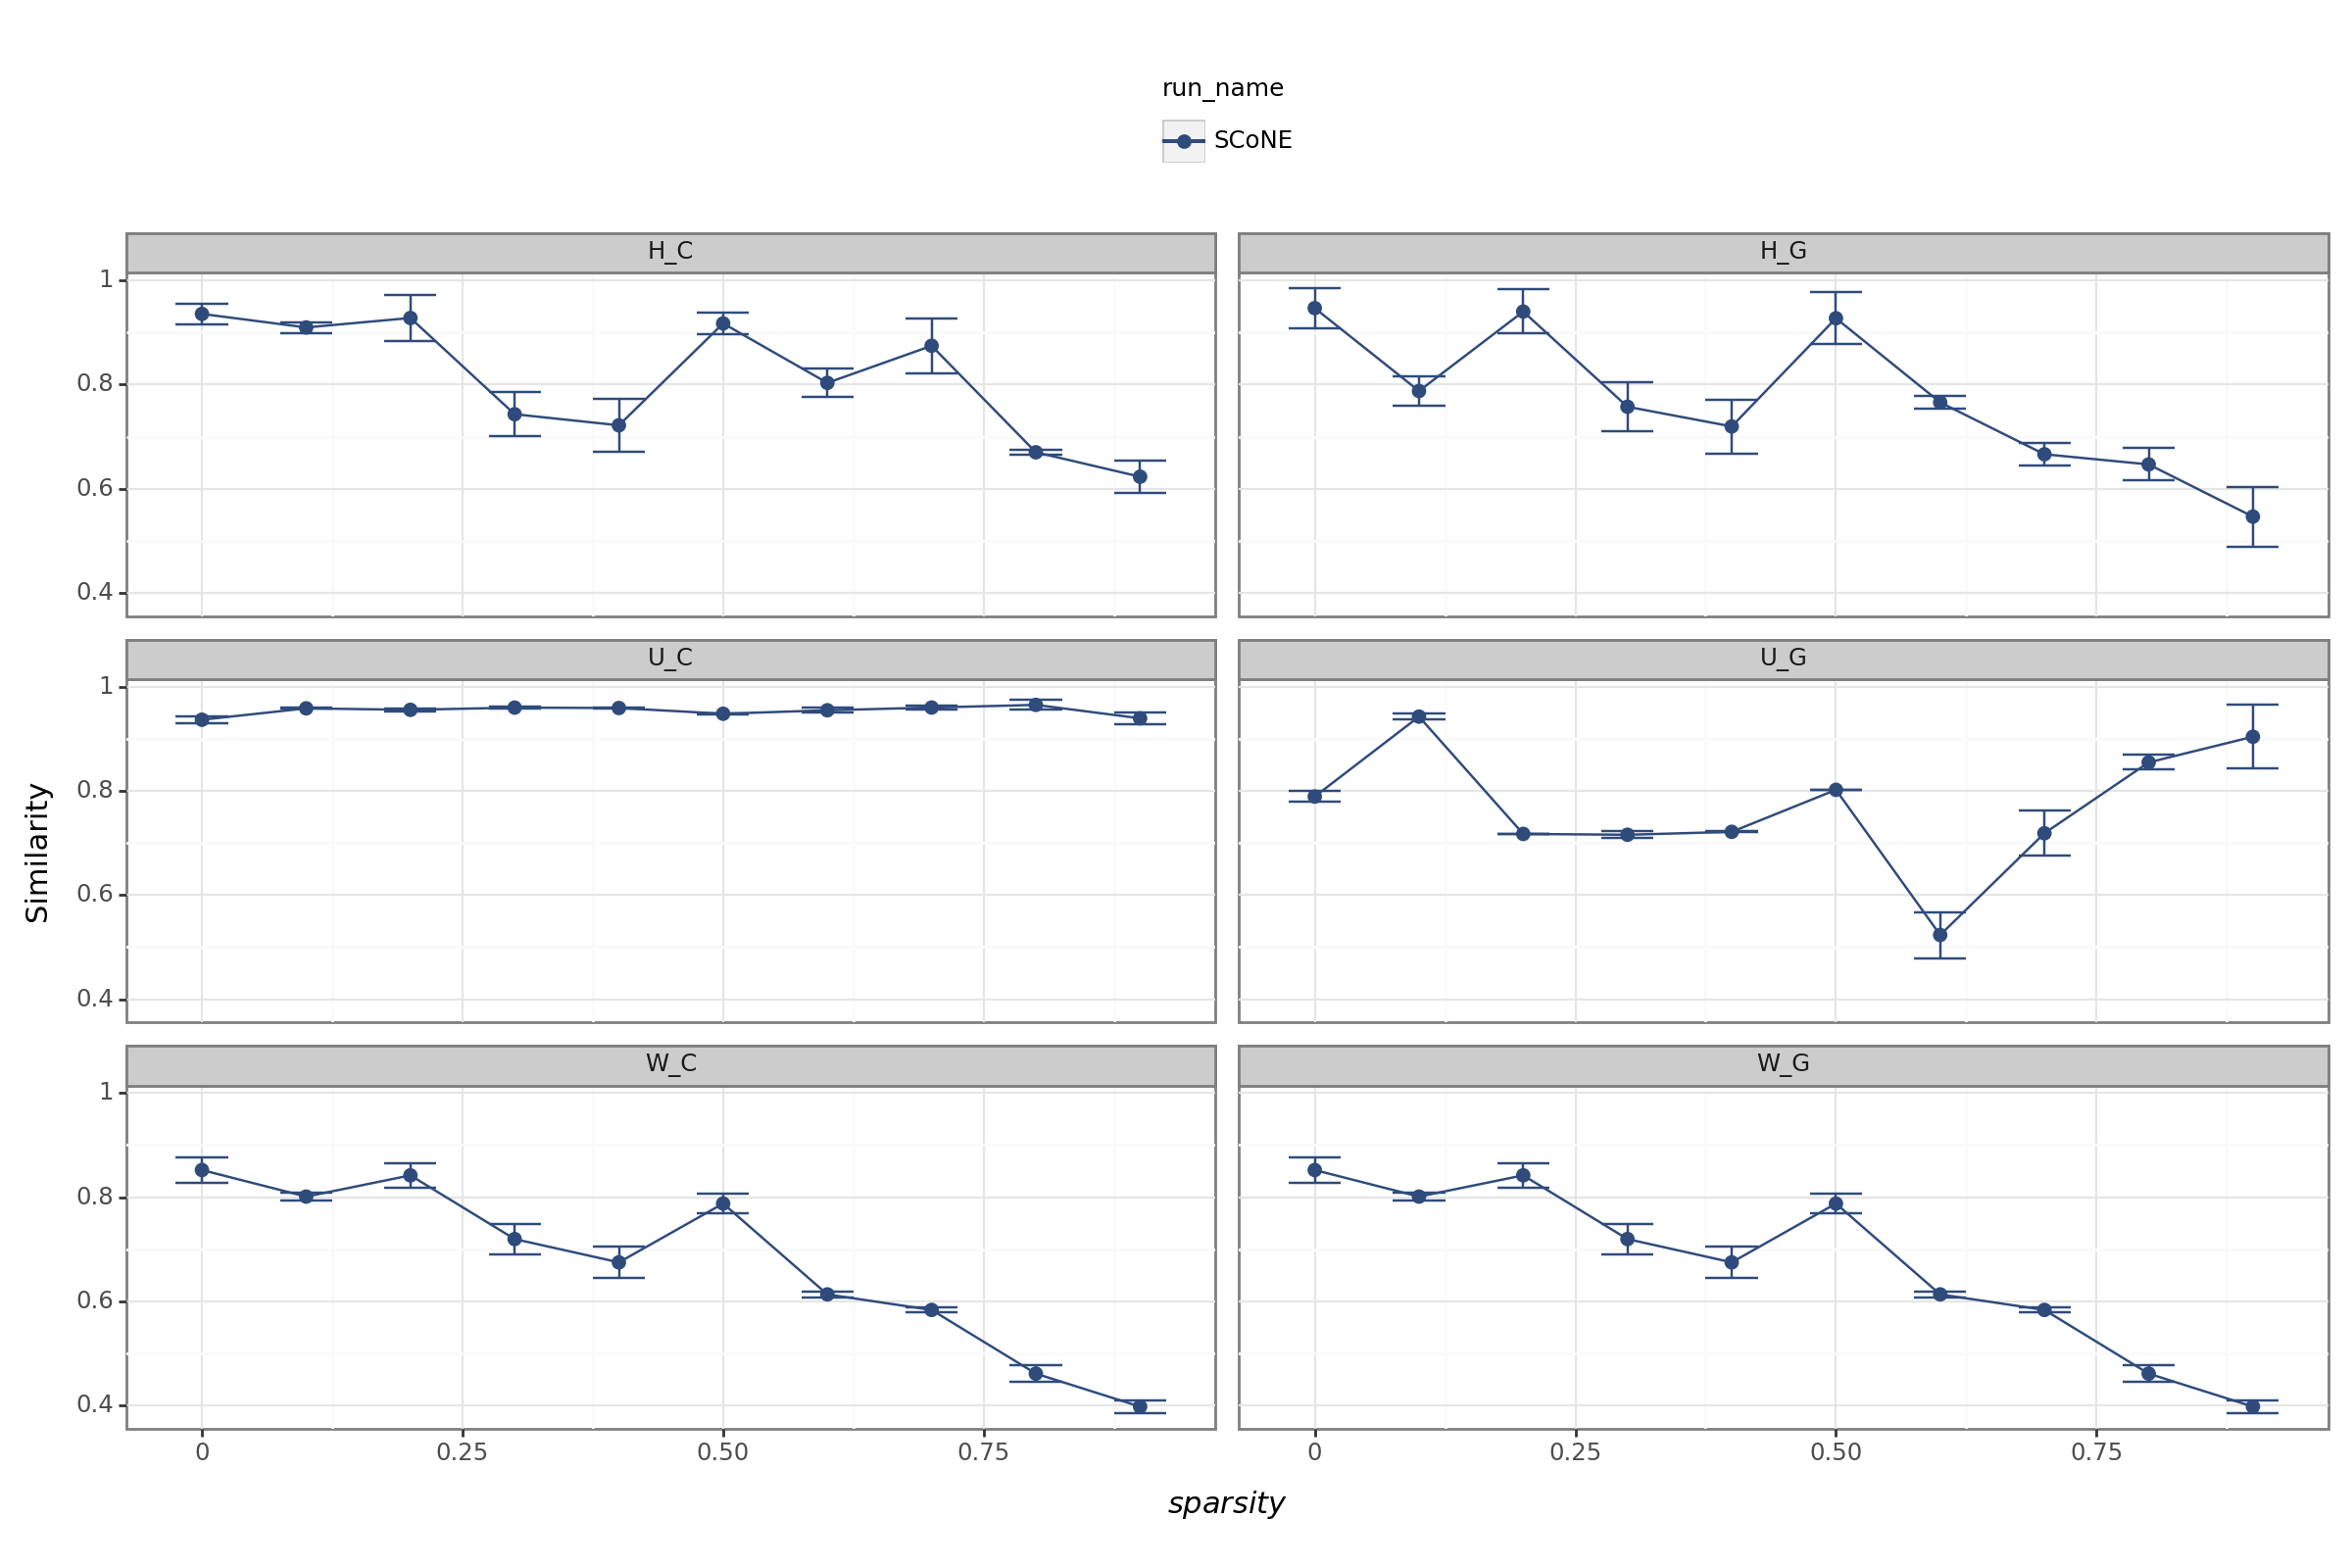

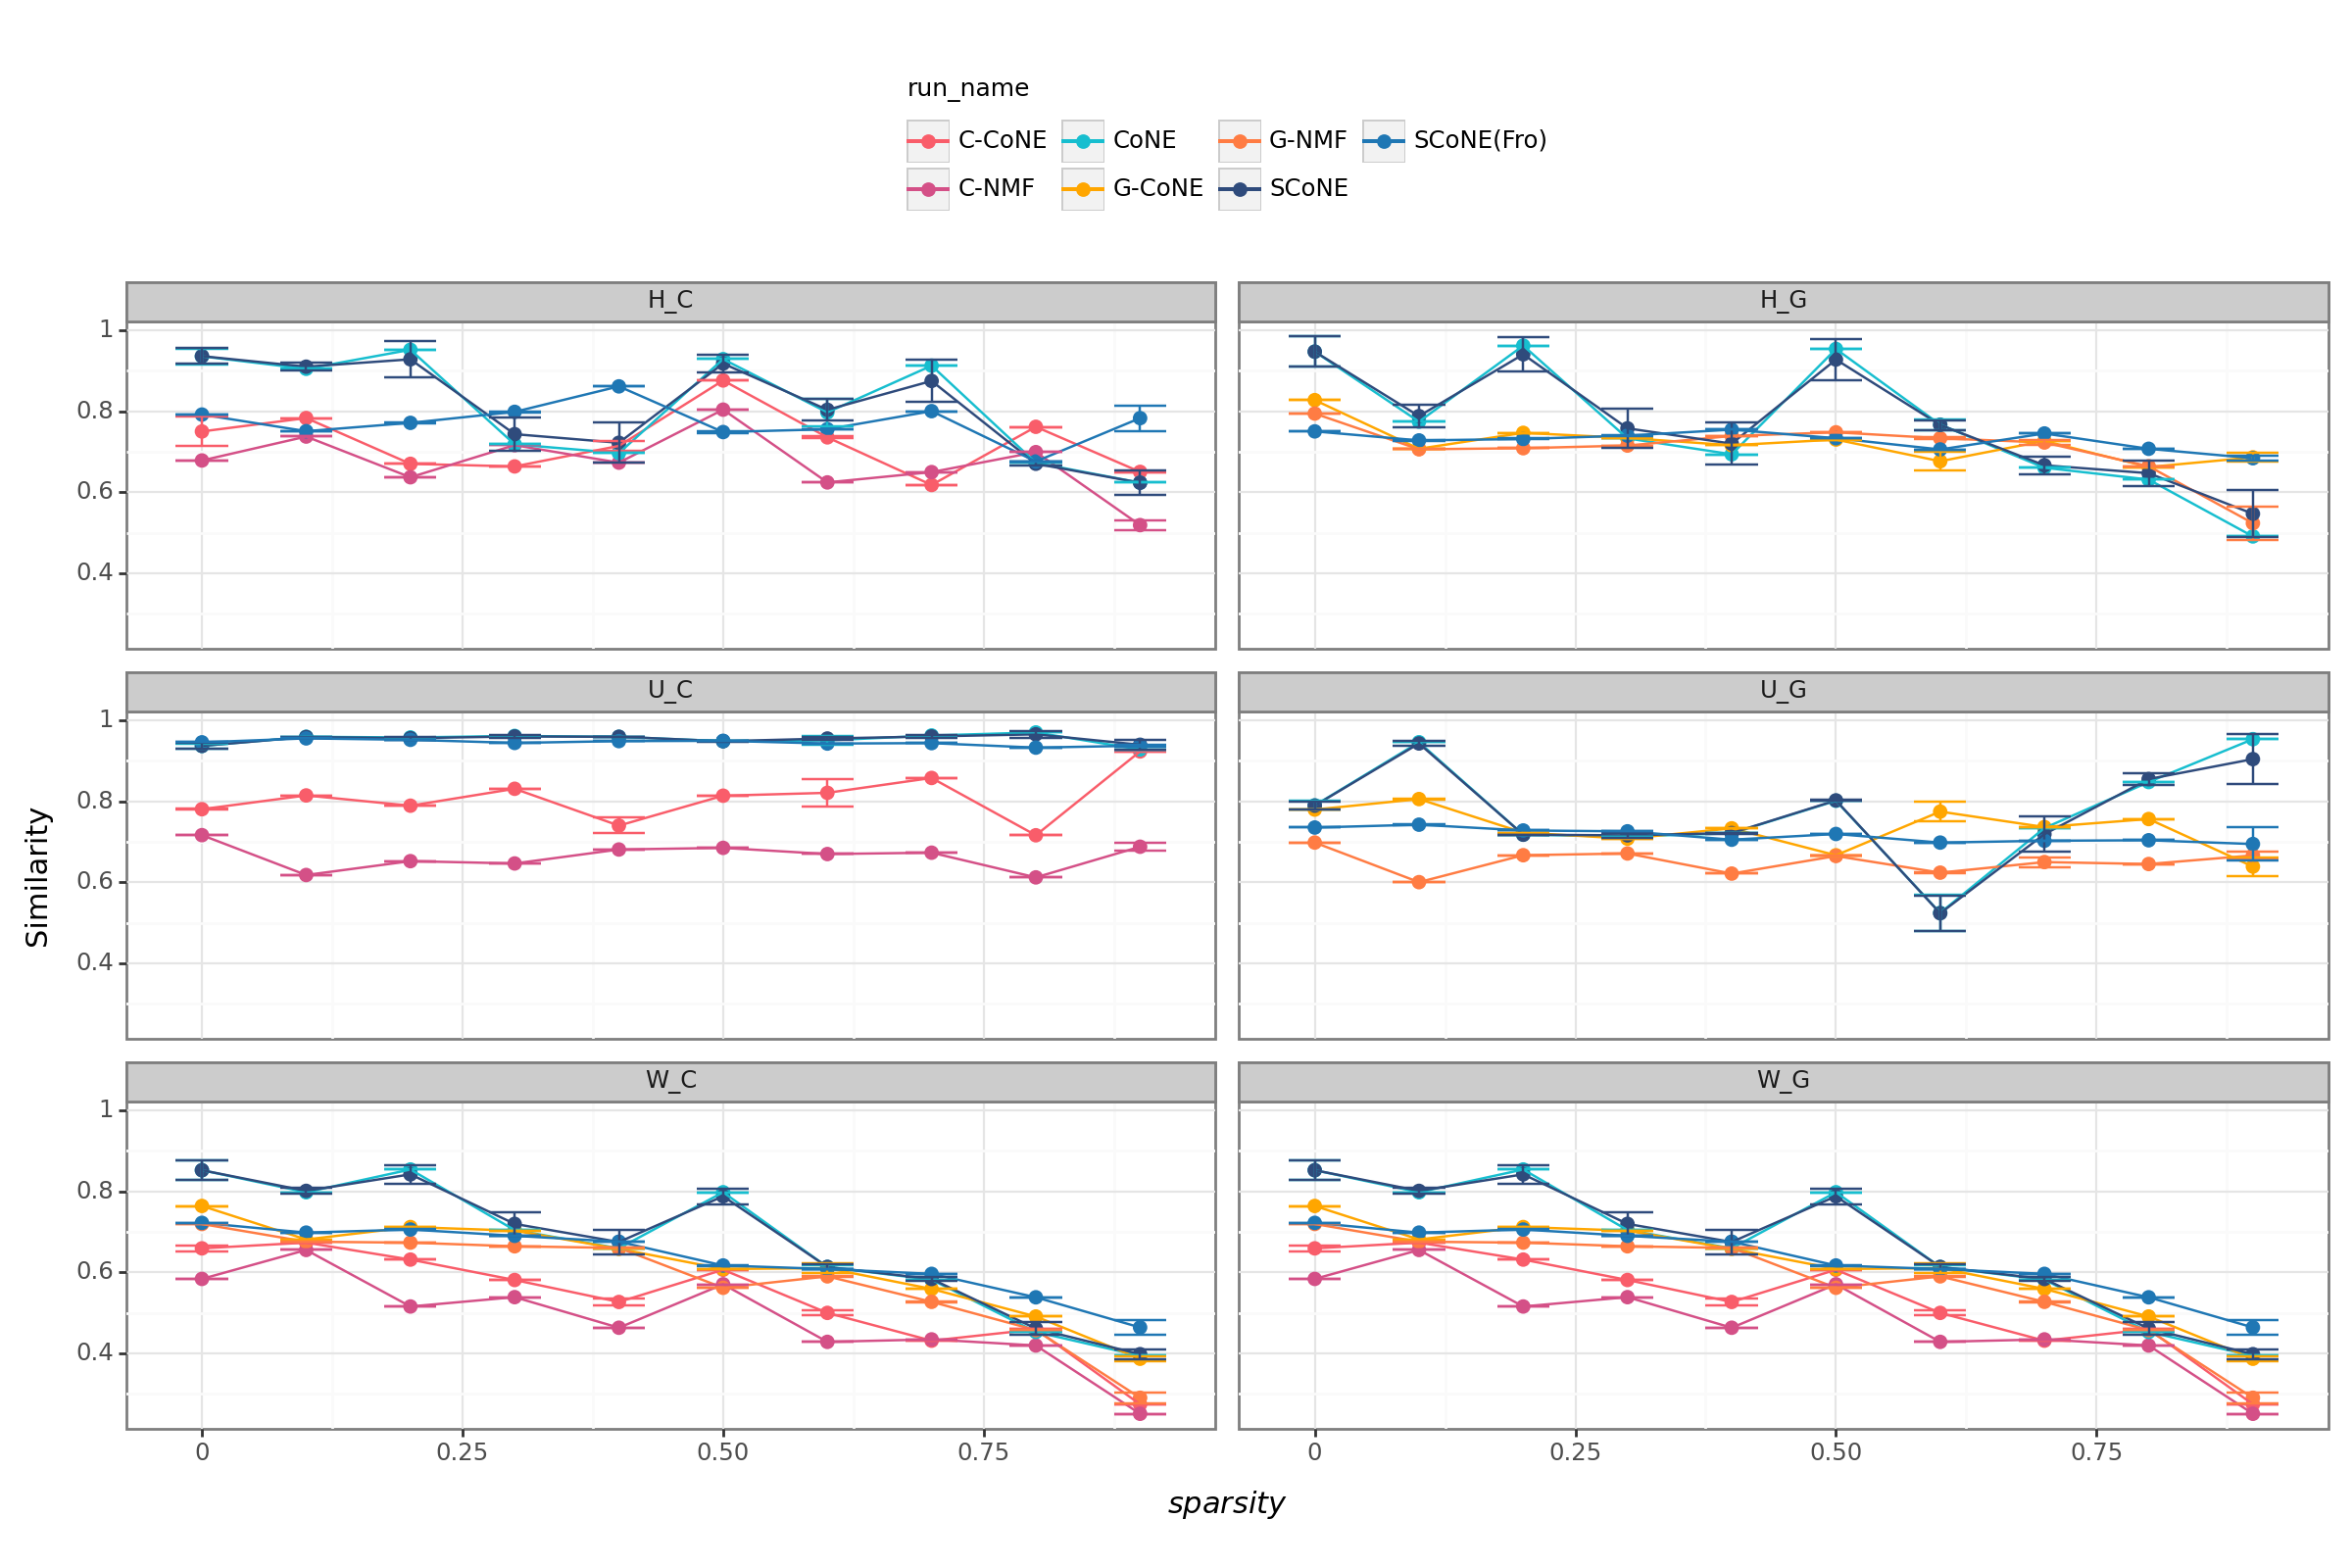

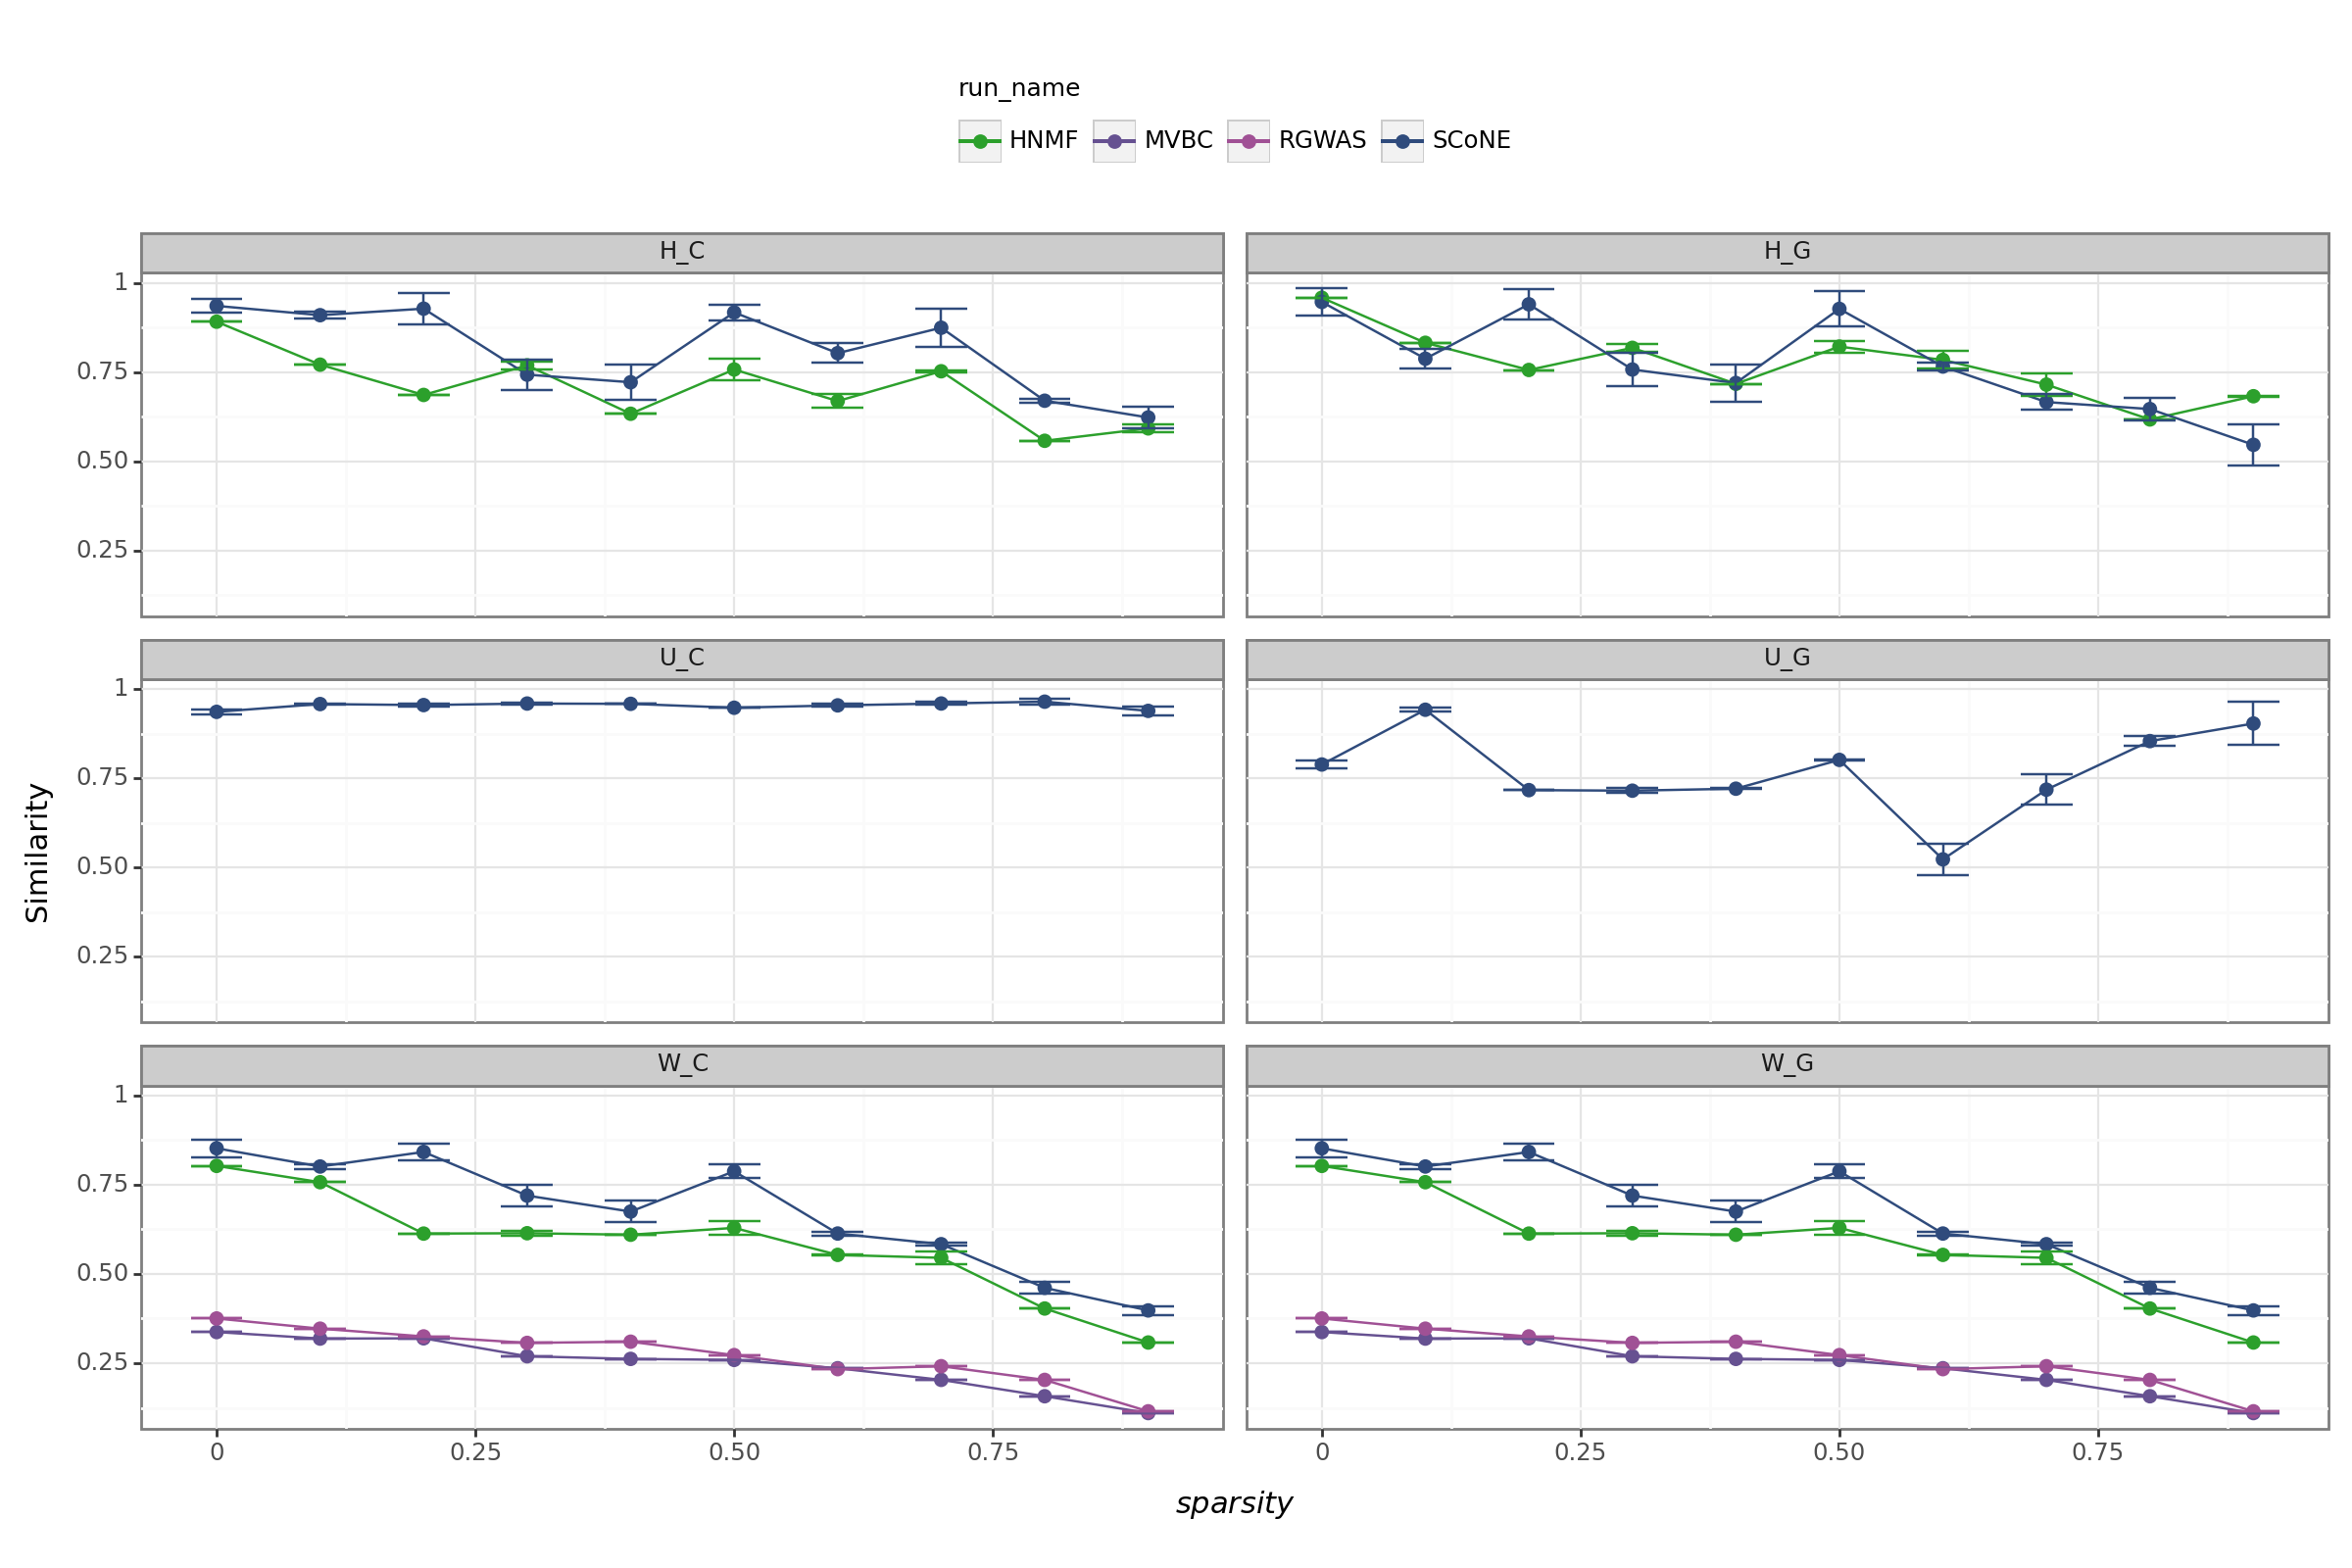

In [3]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/sparsity_summary.csv',index_col=0)
summary = summary[~((summary['run_name']=='HNMF')&(summary['factor_matrix'].str.startswith('U')))]
graph_plots(summary[summary['sparsity']<1],"sparsity",r'$sparsity$')

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 4 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 1 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 4 rows containing missing values.


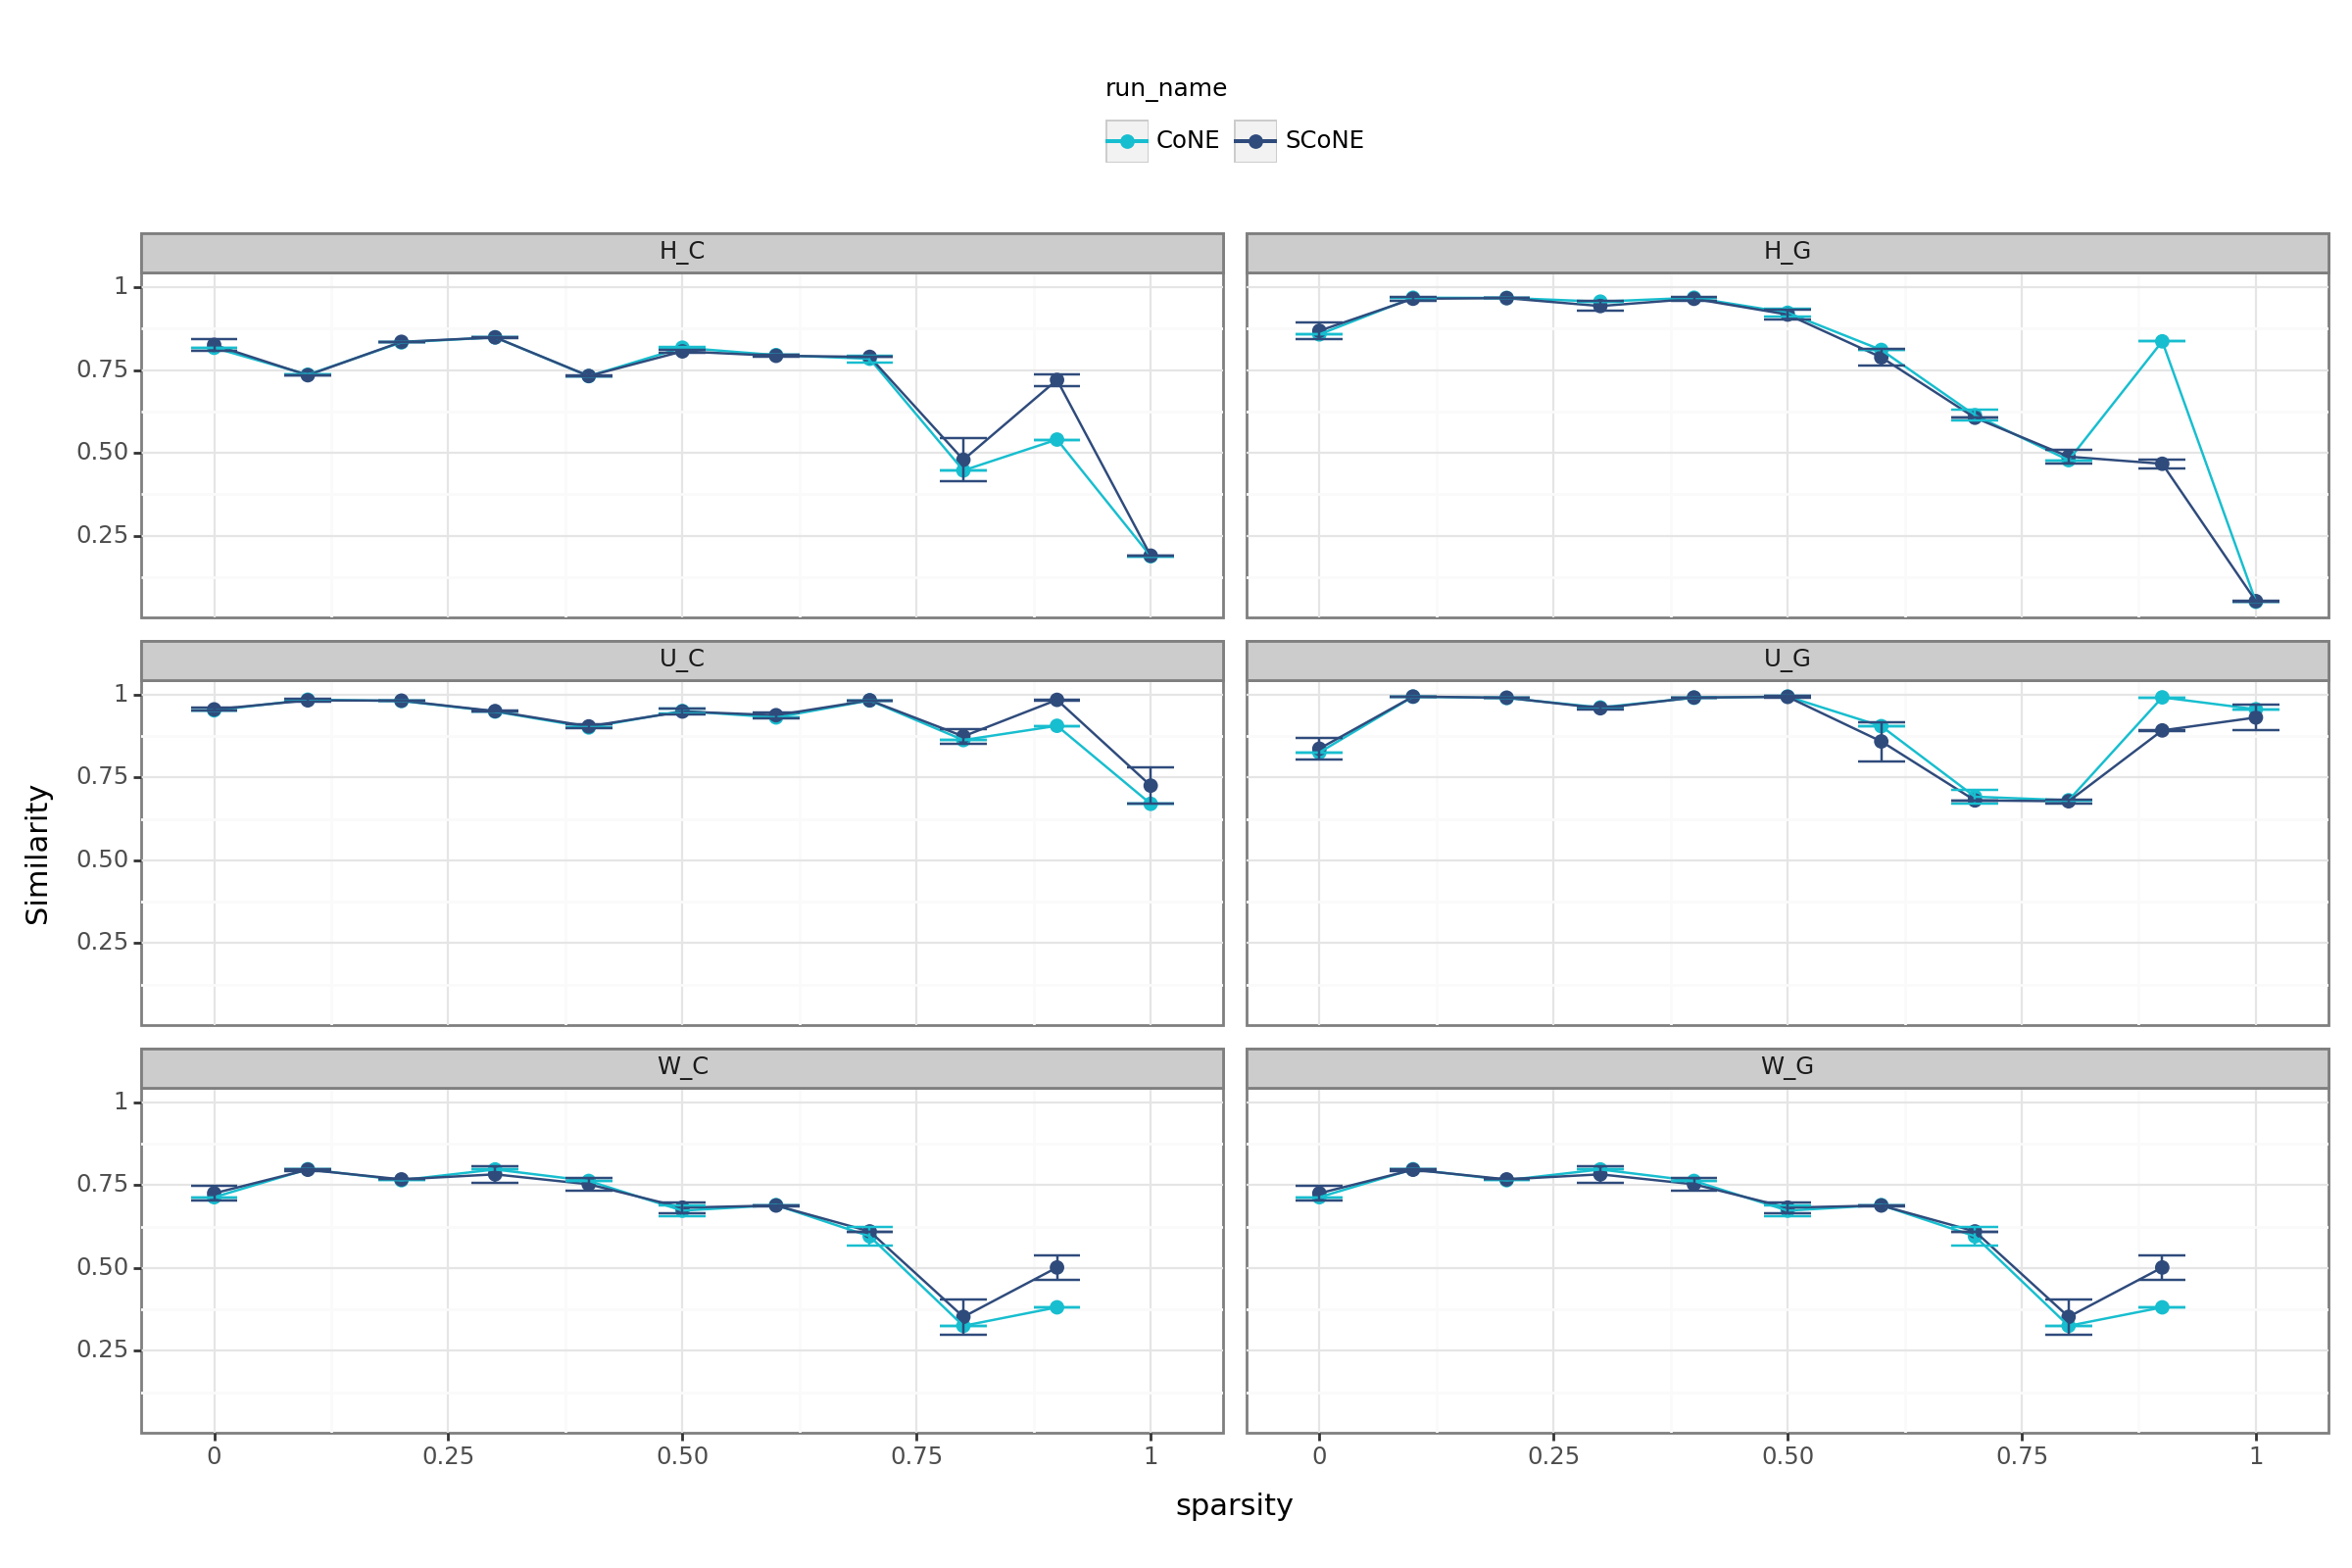

In [20]:
p = (
    ggplot(summary[summary['run_name'].isin(['SCoNE','CoNE'])], aes("sparsity", "mean", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
    + scale_color_manual(values=colors_dict)
    + facet_wrap('factor_matrix',nrow=3)
    + labs(y='Similarity',x="sparsity")
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)